In [ ]:
# =============================================================
# 🧠 Task 1: Wav2vec 2.0 Embedding Feature Extraction Pipeline
# =============================================================

# --- 1. Install Required Libraries ---
# Note: You may already have numpy and pandas installed from the previous notebook.
!pip install pandas numpy librosa torchaudio transformers tqdm openpyxl joblib

# --- 2. Import Libraries ---
import os
import pandas as pd
import numpy as np
import librosa
import torch
import torchaudio
from transformers import Wav2Vec2Processor, Wav2Vec2Model
from tqdm.auto import tqdm
from joblib import Parallel, delayed
import multiprocessing
import warnings
import random

# Suppress minor warnings for cleaner output
warnings.filterwarnings("ignore", category=UserWarning)

# --- 3. Define Paths and Constants ---

# IMPORTANT: Base this on the provided file path structure.
# Your base path for the 'Train' data is: C:\Users\vaish\OneDrive\Desktop\Sem 5\Multi Modal\Project\project2\Train\task1
# We'll use a relative path structure that aligns with the file image, assuming
# a starting point where the 'Train' directory is accessible.
# Since you provided an absolute path for the data location, let's use a dynamic approach
# based on the relative path structure *inside* your project.

# Adjust BASE_DIR according to your specific environment if needed.
# Based on your setup: BASE_DIR = r"C:\Users\vaish\OneDrive\Desktop\Sem 5\Multi Modal\Project\project2\Train\task1"
# For the notebook execution context, we'll keep the relative reference as in the previous notebook:
BASE_DIR = r"Train/task1" 
META_PATH = os.path.join(BASE_DIR, "sand_task_1.xlsx")
TRAIN_DIR = os.path.join(BASE_DIR, "training")
OUTPUT_DIR = BASE_DIR # Save output files in the same base directory

# --- Wav2vec 2.0 Configuration ---
# We use a robust, multilingual model (XLS-R) which performs well on Italian speech
# (the language of the SAND dataset) and typically requires 16kHz audio input.
MODEL_NAME = "facebook/wav2vec2-xls-r-300m"
TARGET_SR = 16000 # Wav2vec 2.0 models typically expect 16kHz
EMBEDDING_DIM = 1024 # The output feature dimension of the XLS-R 300M model

# --- K-Fold Configuration ---
N_SPLITS = 5
RANDOM_STATE = 42

print(f"Base Directory Set to: {BASE_DIR}")
print(f"Wav2vec 2.0 Model: {MODEL_NAME} (Expected SR: {TARGET_SR}Hz, Dim: {EMBEDDING_DIM})")
print("-" * 70)

# Set seed for reproducibility
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_STATE)

     ---------------------------------------- 0.0/44.0 kB ? eta -:--:--
     ------------------------------------- -- 41.0/44.0 kB 2.0 MB/s eta 0:00:01
     -------------------------------------- 44.0/44.0 kB 718.1 kB/s eta 0:00:00
     ---------------------------------------- 0.0/41.5 kB ? eta -:--:--
     -------------------------------------  41.0/41.5 kB 991.0 kB/s eta 0:00:01
     -------------------------------------- 41.5/41.5 kB 336.4 kB/s eta 0:00:00
   ---------------------------------------- 0.0/664.7 kB ? eta -:--:--
   ---------------------------------------- 0.0/664.7 kB ? eta -:--:--
   -- ------------------------------------- 41.0/664.7 kB 1.9 MB/s eta 0:00:01
   --- ------------------------------------ 61.4/664.7 kB 1.1 MB/s eta 0:00:01
   ------- ------------------------------ 122.9/664.7 kB 901.1 kB/s eta 0:00:01
   -------- ----------------------------- 153.6/664.7 kB 833.5 kB/s eta 0:00:01
   ----------- -------------------------- 194.6/664.7 kB 841.6 kB/s eta 0:00


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\vaish\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
C:\Users\vaish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Base Directory Set to: Train/task1
Wav2vec 2.0 Model: facebook/wav2vec2-xls-r-300m (Expected SR: 16000Hz, Dim: 1024)
----------------------------------------------------------------------


In [ ]:
!pip install protobuf


   ---------------------------------------- 0.0/436.9 kB ? eta -:--:--
    --------------------------------------- 10.2/436.9 kB ? eta -:--:--
   --- ----------------------------------- 41.0/436.9 kB 495.5 kB/s eta 0:00:01
   ----- --------------------------------- 61.4/436.9 kB 656.4 kB/s eta 0:00:01
   --------- ---------------------------- 112.6/436.9 kB 731.4 kB/s eta 0:00:01
   ------------- ------------------------ 153.6/436.9 kB 766.6 kB/s eta 0:00:01
   ------------------- ------------------ 225.3/436.9 kB 919.0 kB/s eta 0:00:01
   ---------------------------- ----------- 307.2/436.9 kB 1.1 MB/s eta 0:00:01
   ------------------------------------ --- 399.4/436.9 kB 1.2 MB/s eta 0:00:01
   ---------------------------------------- 436.9/436.9 kB 1.2 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\vaish\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
from transformers import Wav2Vec2FeatureExtractor, Wav2Vec2Model

In [6]:
!pip install hf_xet

   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.9 MB 320.0 kB/s eta 0:00:10
    --------------------------------------- 0.1/2.9 MB 653.6 kB/s eta 0:00:05
   - -------------------------------------- 0.1/2.9 MB 944.1 kB/s eta 0:00:03
   --- ------------------------------------ 0.3/2.9 MB 1.3 MB/s eta 0:00:03
   ------- -------------------------------- 0.5/2.9 MB 2.2 MB/s eta 0:00:02
   --------------- ------------------------ 1.1/2.9 MB 4.0 MB/s eta 0:00:01
   ----------------------------- ---------- 2.1/2.9 MB 6.4 MB/s eta 0:00:01
   ---------------------------------------- 2.9/2.9 MB 8.0 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\vaish\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [14]:
# --- 1. Load Metadata and Create Initial Manifest ---
# Read the initial metadata spreadsheet
try:
    # Use the path defined in Chunk 1
    metadata = pd.read_excel(META_PATH)
    metadata["ID"] = metadata["ID"].astype(str).str.strip()
    valid_ids = set(metadata["ID"].values)
    print("✅ Metadata Loaded.")
except FileNotFoundError:
    print(f"❌ ERROR: Metadata file not found at {META_PATH}")
    raise

# Find audio files and link with metadata (similar logic to original notebook)
audio_data = []
# Folders inside 'training' are the 'Task' types (e.g., phonationA, rhythmKA)
folders = sorted(os.listdir(TRAIN_DIR))

# Process all audio files and link with metadata
for folder in tqdm(folders, desc="Linking Train Audio"):
    folder_path = os.path.join(TRAIN_DIR, folder)
    if not os.path.isdir(folder_path): continue
    for file in os.listdir(folder_path):
        if file.lower().endswith((".wav", ".mp3")): # Check for common audio extensions
            # Extract ID (e.g., 'ID000' from 'ID000_phonationA.wav')
            file_id = file.split("_")[0]
            if file_id in valid_ids:
                row = metadata[metadata["ID"] == file_id].iloc[0]
                audio_data.append({
                    "ID": file_id,
                    "Age": row["Age"],
                    "Sex": row["Sex"],
                    "Class": int(row["Class"]), # Ensure Class is integer type
                    "Task": folder,
                    # Store a relative path for portability
                    "Filepath": os.path.join(folder_path, file).replace(os.path.sep, '/')
                })

df_manifest = pd.DataFrame(audio_data)
df_manifest['Class'] = df_manifest['Class'].astype(int)

# Check the distribution and save the manifest
print(f"\n✅ Train Manifest Created (Rows: {len(df_manifest)})")
print("Class Distribution:\n", df_manifest['Class'].value_counts().sort_index())

MANIFEST_PATH = os.path.join(OUTPUT_DIR, "wav2vec_train_manifest.csv")
df_manifest.to_csv(MANIFEST_PATH, index=False)
print(f"💾 Manifest saved to: {MANIFEST_PATH}")
print("-" * 70)


# --- 2. Initialize Wav2vec 2.0 Model and Processor ---

# Load feature extractor and model from HuggingFace
# try:
#     # The processor handles loading, resampling, and padding/truncation
#     processor = Wav2Vec2Processor.from_pretrained(MODEL_NAME)
#     # The model extracts the actual embeddings (the features)
#     model = Wav2Vec2Model.from_pretrained(MODEL_NAME)
#     model.eval() # Set model to evaluation mode
#     print(f"✅ Wav2vec 2.0 Model and Processor loaded: {MODEL_NAME}")
    
#     # Check for GPU and move model if available
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#     model.to(device)
#     print(f"✅ Running on device: {device}")
    
# except Exception as e:
#     print(f"❌ ERROR: Failed to load Wav2vec 2.0 components. Ensure you have PyTorch and Transformers correctly installed.")
#     print(f"Details: {e}")
#     raise

# print("-" * 70)

try:
    # Use FeatureExtractor instead of Processor for Classification tasks
    # This avoids the error if the model has no tokenizer/vocab
    feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(MODEL_NAME)
    
    model = Wav2Vec2Model.from_pretrained(MODEL_NAME)
    model.eval()
    
    print(f"✅ Wav2vec 2.0 Model and Feature Extractor loaded: {MODEL_NAME}")
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    print(f"✅ Running on device: {device}")
    
except Exception as e:
    print(f"❌ ERROR: Failed to load components.")
    print(f"Details: {e}")
    raise

✅ Metadata Loaded.


Linking Train Audio: 100%|██████████| 8/8 [00:00<00:00, 28.09it/s]



✅ Train Manifest Created (Rows: 2176)
Class Distribution:
 Class
1     48
2    208
3    456
4    608
5    856
Name: count, dtype: int64
💾 Manifest saved to: Train/task1\wav2vec_train_manifest.csv
----------------------------------------------------------------------
✅ Wav2vec 2.0 Model and Feature Extractor loaded: facebook/wav2vec2-xls-r-300m
✅ Running on device: cpu


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


In [9]:
# --- 1. Define the Feature Extraction Worker Function ---
def extract_wav2vec_features(filepath, model, processor, target_sr, device):
    """
    Loads a single audio file, extracts Wav2vec 2.0 embeddings, and returns 
    the mean-pooled vector (fixed-length embedding).
    """
    import torch
    import librosa
    import numpy as np
    import os
    
    # Ensure the path is correct
    full_path = os.path.normpath(os.path.join(BASE_DIR, filepath))
    
    try:
        # Load and resample the audio to the model's expected SR (16kHz)
        speech, sr = librosa.load(full_path, sr=target_sr)

        # Preprocess the audio: convert to tensor, normalize (done by processor)
        # return_tensors="pt" gives a PyTorch tensor
        inputs = processor(
            speech, 
            sampling_rate=target_sr, 
            return_tensors="pt"
        )
        
        # Move inputs to the same device as the model (GPU or CPU)
        input_values = inputs.input_values.to(device)

        with torch.no_grad():
            # Get the hidden states from the final layer
            # We use .last_hidden_state for the contextualized embedding
            outputs = model(input_values)
            last_hidden_state = outputs.last_hidden_state.squeeze(0)
            
            # --- Mean Pooling (Aggregation) ---
            # Calculate the mean across the sequence length (axis 0) to get a 
            # single fixed-size vector for the entire audio clip.
            mean_pooled_embedding = last_hidden_state.mean(dim=0)
            
            # Convert to numpy and return
            return mean_pooled_embedding.cpu().numpy()
            
    except Exception as e:
        # Fallback to a vector of NaNs on failure
        # Size must match EMBEDDING_DIM (1024)
        # print(f"Error processing {filepath}: {e}")
        return np.full(EMBEDDING_DIM, np.nan, dtype=np.float32)

# --- 2. Main Parallel Execution ---
# Use all available cores except 1 for stability
num_cores = multiprocessing.cpu_count() - 1 if multiprocessing.cpu_count() > 1 else 1

print(f"🚀 Starting Parallel Wav2vec 2.0 Extraction on {len(df_manifest)} files using {num_cores} cores...")

# Prepare list of filepaths for parallel processing
filepaths = df_manifest['Filepath'].tolist()

# The model and processor are large objects and cannot be pickled/passed easily,
# but `joblib`'s `loky` backend handles this by passing references/spawning new processes.
# We pass the shared objects (model, processor) once.
all_embeddings = Parallel(n_jobs=num_cores, verbose=10)(
    delayed(extract_wav2vec_features)(
        fp, model, processor, TARGET_SR, device
    ) for fp in filepaths
)

# Convert the list of arrays into a single DataFrame
df_embeddings = pd.DataFrame(all_embeddings)

# --- 3. Consolidation and Cleanup ---
# Identify and handle failed/NaN rows
nan_mask = df_embeddings.isnull().all(axis=1)
num_failed = nan_mask.sum()
if num_failed > 0:
    print(f"\n⚠️ WARNING: {num_failed} files failed extraction (NaN rows). These will be removed.")
    df_manifest = df_manifest[~nan_mask].reset_index(drop=True)
    df_embeddings = df_embeddings[~nan_mask].reset_index(drop=True)

# Rename embedding columns
df_embeddings.columns = [f'wav2vec_{i}' for i in range(EMBEDDING_DIM)]

# Final merge
df_final_features = pd.concat([df_manifest[['ID', 'Class', 'Task']], df_embeddings], axis=1)

# Save the extracted features
FEATURES_PATH = os.path.join(OUTPUT_DIR, "wav2vec_audio_features.csv")
df_final_features.to_csv(FEATURES_PATH, index=False)

print(f"\n✅ Extraction complete. Final shape: {df_final_features.shape}")
print(f"💾 Features saved to: {FEATURES_PATH}")
print("-" * 70)

🚀 Starting Parallel Wav2vec 2.0 Extraction on 2176 files using 19 cores...


[Parallel(n_jobs=19)]: Using backend LokyBackend with 19 concurrent workers.


NameError: name 'processor' is not defined

In [18]:
import torch
import librosa
import numpy as np
import pandas as pd
import os
from tqdm import tqdm

# --- 1. Define the Feature Extraction Function ---
def get_embedding(filepath, model, feature_extractor, target_sr, device):
    """
    Loads audio, passes it through the model, and returns the mean-pooled embedding.
    """
    # Construct full path (assuming filepath in manifest is relative to BASE_DIR)
    # If filepath is already absolute, os.path.join handles it correctly anyway
    full_path = os.path.join(filepath)
    
    try:
        # 1. Load Audio
        speech, sr = librosa.load(full_path, sr=target_sr)

        # 2. Preprocess (Feature Extractor)
        # return_tensors="pt" creates PyTorch tensors
        inputs = feature_extractor(
            speech, 
            sampling_rate=target_sr, 
            return_tensors="pt", 
            padding=True
        )
        
        # 3. Move inputs to GPU/CPU
        input_values = inputs.input_values.to(device)

        # 4. Model Inference
        with torch.no_grad():
            outputs = model(input_values)
            # last_hidden_state shape: (Batch_Size, Sequence_Length, Hidden_Dim)
            last_hidden_state = outputs.last_hidden_state.squeeze(0)
            
            # 5. Mean Pooling
            # Average over time (axis 0) to get one vector per audio file
            mean_pooled_embedding = last_hidden_state.mean(dim=0)
            
            return mean_pooled_embedding.cpu().numpy()
            
    except Exception as e:
        print(f"⚠️ Error processing {filepath}: {e}")
        return None

# --- 2. Sequential Execution (GPU Safe) ---

print(f"🚀 Starting Wav2vec 2.0 Extraction on {len(df_manifest)} files...")
print(f"   Device: {device}")

embeddings_list = []
valid_indices = []

# We use a standard loop instead of Parallel/joblib to avoid CUDA/Pickling errors
for idx, row in tqdm(df_manifest.iterrows(), total=len(df_manifest), desc="Extracting Features"):
    
    emb = get_embedding(
        row['Filepath'], 
        model, 
        feature_extractor, 
        TARGET_SR, # Ensure this variable is defined (usually 16000)
        device
    )
    
    if emb is not None:
        embeddings_list.append(emb)
        valid_indices.append(idx)

# --- 3. Consolidation and Cleanup ---

if len(embeddings_list) == 0:
    raise ValueError("❌ No embeddings were extracted. Check your file paths or audio files.")

# Convert list of arrays to DataFrame
df_embeddings = pd.DataFrame(embeddings_list)

# Determine Embedding Dimension dynamically (e.g., 768 for Base, 1024 for Large)
embedding_dim = df_embeddings.shape[1]
print(f"ℹ️ Detected Embedding Dimension: {embedding_dim}")

# Rename columns
df_embeddings.columns = [f'wav2vec_{i}' for i in range(embedding_dim)]

# Filter the original manifest to match successfully processed files
df_manifest_clean = df_manifest.iloc[valid_indices].reset_index(drop=True)

# Merge Metadata with Embeddings
df_final_features = pd.concat([df_manifest_clean[['ID', 'Class', 'Task']], df_embeddings], axis=1)

# Save the extracted features
FEATURES_PATH = os.path.join(OUTPUT_DIR, "wav2vec_audio_features.csv")
df_final_features.to_csv(FEATURES_PATH, index=False)

print(f"\n✅ Extraction complete.")
print(f"   Original Files: {len(df_manifest)}")
print(f"   Successful:     {len(df_final_features)}")
print(f"   Failed/Skipped: {len(df_manifest) - len(df_final_features)}")
print(f"💾 Features saved to: {FEATURES_PATH}")
print("-" * 70)

🚀 Starting Wav2vec 2.0 Extraction on 2176 files...
   Device: cpu


Extracting Features: 100%|██████████| 2176/2176 [8:19:22<00:00, 13.77s/it]      


ℹ️ Detected Embedding Dimension: 1024

✅ Extraction complete.
   Original Files: 2176
   Successful:     2176
   Failed/Skipped: 0
💾 Features saved to: Train/task1\wav2vec_audio_features.csv
----------------------------------------------------------------------


In [19]:
import torch
import librosa
import numpy as np
import pandas as pd
import os
from joblib import Parallel, delayed
import multiprocessing

# --- 1. Define the Worker Function ---
def extract_single_file(filepath, model, feature_extractor, target_sr, device):
    """
    Worker function to process a single audio file.
    """
    try:
        # Load audio (Librosa is not thread-safe by default, but safe enough here)
        speech, sr = librosa.load(filepath, sr=target_sr)

        # Preprocess
        inputs = feature_extractor(
            speech, 
            sampling_rate=target_sr, 
            return_tensors="pt", 
            padding=True
        )
        
        # Move to Device
        input_values = inputs.input_values.to(device)

        # Model Inference (PyTorch releases GIL here, allowing parallelism)
        with torch.no_grad():
            outputs = model(input_values)
            last_hidden_state = outputs.last_hidden_state.squeeze(0)
            mean_pooled = last_hidden_state.mean(dim=0)
            
            return mean_pooled.cpu().numpy()

    except Exception as e:
        # print(f"⚠️ Error on {filepath}: {e}") # Uncomment to debug
        return None

# --- 2. Main Parallel Execution ---

# Determine cores (leave 1 free for OS)
num_cores = multiprocessing.cpu_count() - 1 if multiprocessing.cpu_count() > 1 else 1
print(f"🚀 Starting Parallel Extraction on {len(df_manifest)} files using {num_cores} threads...")

# Prepare filepaths (Fixing the path issue: assume filepath in CSV is the full relative path)
filepaths = df_manifest['Filepath'].tolist()

# Run Parallel Loop
# prefer="threads" is CRITICAL here to share the model memory across workers
results = Parallel(n_jobs=num_cores, prefer="threads", verbose=5)(
    delayed(extract_single_file)(
        fp, model, feature_extractor, TARGET_SR, device
    ) for fp in filepaths
)

# --- 3. Consolidation & Aggregation ---

# Filter out None results (failed files)
valid_results = [r for r in results if r is not None]
valid_indices = [i for i, r in enumerate(results) if r is not None]

if not valid_results:
    raise ValueError("❌ No embeddings extracted. Check file paths.")

# Create DataFrame
df_embeddings = pd.DataFrame(valid_results)
embedding_dim = df_embeddings.shape[1]
df_embeddings.columns = [f'wav2vec_{i}' for i in range(embedding_dim)]

# Filter Metadata
df_manifest_clean = df_manifest.iloc[valid_indices].reset_index(drop=True)

# Merge
df_final_features = pd.concat([df_manifest_clean[['ID', 'Class', 'Task']], df_embeddings], axis=1)

print(f"\n✅ Extraction Complete. Processed: {len(df_final_features)}")

# --- 4. Aggregation (Subject Level) ---
print("🔄 Aggregating by Subject ID...")
aggregation_dict = {
    'Class': 'first',
    **{col: 'mean' for col in df_embeddings.columns}
}

df_master = df_final_features.drop(columns=['Task']).groupby('ID').agg(aggregation_dict).reset_index()

# Save
FEATURES_PATH = os.path.join(OUTPUT_DIR, "Task1_WAV2VEC_MASTER_FEATURES.csv")
df_master.to_csv(FEATURES_PATH, index=False)
print(f"💾 Saved Master Features to: {FEATURES_PATH}")

🚀 Starting Parallel Extraction on 2176 files using 19 threads...


[Parallel(n_jobs=19)]: Using backend ThreadingBackend with 19 concurrent workers.
[Parallel(n_jobs=19)]: Done  34 tasks      | elapsed:   58.4s
[Parallel(n_jobs=19)]: Done 124 tasks      | elapsed:  2.7min
[Parallel(n_jobs=19)]: Done 250 tasks      | elapsed:  5.2min
[Parallel(n_jobs=19)]: Done 412 tasks      | elapsed:  8.1min
[Parallel(n_jobs=19)]: Done 610 tasks      | elapsed: 11.8min
[Parallel(n_jobs=19)]: Done 844 tasks      | elapsed: 16.3min
[Parallel(n_jobs=19)]: Done 1114 tasks      | elapsed: 21.5min
[Parallel(n_jobs=19)]: Done 1420 tasks      | elapsed: 27.2min
[Parallel(n_jobs=19)]: Done 1762 tasks      | elapsed: 34.2min
[Parallel(n_jobs=19)]: Done 2176 out of 2176 | elapsed: 42.9min finished



✅ Extraction Complete. Processed: 2176
🔄 Aggregating by Subject ID...
💾 Saved Master Features to: Train/task1\Task1_WAV2VEC_MASTER_FEATURES.csv


In [21]:
!pip install xgboost

   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB 435.7 kB/s eta 0:02:46
   ---------------------------------------- 0.1/72.0 MB 1.1 MB/s eta 0:01:06
   ---------------------------------------- 0.3/72.0 MB 1.7 MB/s eta 0:00:42
   ---------------------------------------- 0.5/72.0 MB 2.8 MB/s eta 0:00:26
    --------------------------------------- 1.1/72.0 MB 4.5 MB/s eta 0:00:16
   - -------------------------------------- 2.5/72.0 MB 9.0 MB/s eta 0:00:08
   -- ------------------------------------- 3.7/72.0 MB 11.9 MB/s eta 0:00:06
   --- ------------------------------------ 5.9/72.0 MB 16.4 MB/s eta 0:00:05
   ---- ----------------------------------- 8.4/72.0 MB 20.6 MB/s eta 0:00:04
   ----- ---------------------------------- 10.3/72.0 MB 28.4 MB/s eta 0:00:03
   ------- -------------------------------- 13.0/72.0 MB 54.7 MB/s eta 0:00:02
   -


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\vaish\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [23]:
# --- 1. Import necessary libraries for ML ---
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import RobustScaler
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, make_scorer
import pandas as pd
import numpy as np
import os

# --- 2. Configuration ---
FEATURES_PATH = os.path.join(BASE_DIR, "Task1_WAV2VEC_MASTER_FEATURES.csv")
N_SPLITS = 5
RANDOM_STATE = 42

# --- 3. Load Data ---
try:
    df_master = pd.read_csv(FEATURES_PATH)
    if df_master.shape[0] == 0:
        raise ValueError("Master features DataFrame is empty.")
    print(f"✅ Loaded Master Features. Shape: {df_master.shape}")
except FileNotFoundError:
    print(f"❌ ERROR: Master feature file not found at {FEATURES_PATH}. Check Chunk 3 output.")
    raise
except ValueError as e:
    print(f"❌ ERROR: {e}")
    raise

# --- 4. Prepare X and y ---
X = df_master.drop(columns=['ID', 'Class'])
# Convert Class 1-5 to 0-4 for XGBoost (required for multi-class classification)
y = df_master['Class'] - 1

print(f"Class Distribution in y (0-4): \n{y.value_counts().sort_index()}")

# --- 5. Feature Scaling ---
# Scale the high-dimensional Wav2vec 2.0 embeddings
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("✅ Features scaled using RobustScaler.")

# --- 6. Model Definition ---
# Use parameters suitable for a high-dimensional feature set
xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=5,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=2,
    gamma=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    tree_method='hist' # Efficient tree method
)

# --- 7. K-Fold Cross-Validation ---
# Create a custom scorer for Macro F1-score
macro_f1_scorer = make_scorer(f1_score, average='macro')

# Stratified split is crucial for class imbalance
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

print(f"\n🚀 Starting {N_SPLITS}-Fold Stratified Cross-Validation (Metric: Macro F1-score)...")

# Perform cross-validation
cv_scores = cross_val_score(
    xgb_model, 
    X_scaled, # Use scaled features for improved performance
    y, 
    cv=cv, 
    scoring=macro_f1_scorer, 
    n_jobs=-1, # Use all available cores for CV folds
    verbose=1
)

# --- 8. Results Summary ---
print("\n--- Cross-Validation Results (Wav2vec 2.0 + XGBoost) ---")
print(f"Individual Fold Macro F1 Scores: {np.round(cv_scores, 4)}")
print(f"Average Macro F1 Score: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")
print("-" * 70)

✅ Loaded Master Features. Shape: (272, 1026)
Class Distribution in y (0-4): 
Class
0      6
1     26
2     57
3     76
4    107
Name: count, dtype: int64
✅ Features scaled using RobustScaler.

🚀 Starting 5-Fold Stratified Cross-Validation (Metric: Macro F1-score)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:   23.7s remaining:   35.6s



--- Cross-Validation Results (Wav2vec 2.0 + XGBoost) ---
Individual Fold Macro F1 Scores: [0.3592 0.247  0.249  0.3561 0.4604]
Average Macro F1 Score: 0.3343 (+/- 0.0799)
----------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   24.3s finished


In [26]:
!pip install imblearn

   ---------------------------------------- 0.0/240.0 kB ? eta -:--:--
   ----- ---------------------------------- 30.7/240.0 kB 1.3 MB/s eta 0:00:01
   --------------- ------------------------ 92.2/240.0 kB 1.3 MB/s eta 0:00:01
   ---------------------------------------- 240.0/240.0 kB 2.1 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\vaish\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [27]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import f1_score, make_scorer, confusion_matrix, classification_report
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler

# --- Configuration ---
# Update this to your actual path if needed
BASE_DIR = r"Train/task1"
FEATURES_PATH = os.path.join(BASE_DIR, "Task1_WAV2VEC_MASTER_FEATURES.csv")
N_SPLITS = 5
RANDOM_STATE = 42

# --- 1. Load Data ---
if not os.path.exists(FEATURES_PATH):
    print(f"❌ Error: File not found at {FEATURES_PATH}")
else:
    df_master = pd.read_csv(FEATURES_PATH)
    print(f"✅ Data Loaded. Shape: {df_master.shape}")

    # Prepare X and y
    X = df_master.drop(columns=['ID', 'Class'])
    # Ensure y is 0-4 for XGBoost
    le = LabelEncoder()
    y = le.fit_transform(df_master['Class'])
    
    # Check for the minority class size to safely configure SMOTE
    min_class_size = np.min(np.bincount(y))
    print(f"ℹ️ Minority class has {min_class_size} samples.")

    # --- 2. Define Pipelines ---

    # PIPELINE 1: Improved XGBoost
    # - PCA: Reduces 1024 features to ~50-100 essential components
    # - RandomOverSampler: Safe for tiny classes (like Class 1 with 6 samples) where SMOTE fails
    xgb_pipeline = ImbPipeline([
        ('scaler', RobustScaler()),
        ('pca', PCA(n_components=0.95, random_state=RANDOM_STATE)), # Keep 95% variance
        ('sampler', RandomOverSampler(random_state=RANDOM_STATE)), # Duplicate minority samples
        ('classifier', XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.6,
            eval_metric='mlogloss',
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

    # PIPELINE 2: Support Vector Machine (SVM)
    # - SVMs are often superior for High-Dimension/Low-Sample Count tasks
    # - 'class_weight="balanced"' handles imbalance automatically
    svm_pipeline = ImbPipeline([
        ('scaler', RobustScaler()),
        ('pca', PCA(n_components=0.95, random_state=RANDOM_STATE)),
        ('sampler', RandomOverSampler(random_state=RANDOM_STATE)),
        ('classifier', SVC(
            kernel='rbf',
            C=10.0,          # Regularization (Higher = stricter)
            gamma='scale', 
            class_weight='balanced',
            probability=True,
            random_state=RANDOM_STATE
        ))
    ])

    # --- 3. Evaluation Loop ---
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    scorer = make_scorer(f1_score, average='macro')

    print(f"\n🚀 Running {N_SPLITS}-Fold CV on {len(X)} samples...")

    # Evaluate XGBoost
    print("\n--- 1. XGBoost with PCA & Oversampling ---")
    xgb_scores = cross_val_score(xgb_pipeline, X, y, cv=cv, scoring=scorer, n_jobs=-1)
    print(f"Scores: {np.round(xgb_scores, 4)}")
    print(f"🔥 Average Macro F1: {np.mean(xgb_scores):.4f} (+/- {np.std(xgb_scores):.4f})")

    # Evaluate SVM
    print("\n--- 2. SVM with PCA & Oversampling ---")
    svm_scores = cross_val_score(svm_pipeline, X, y, cv=cv, scoring=scorer, n_jobs=-1)
    print(f"Scores: {np.round(svm_scores, 4)}")
    print(f"🔥 Average Macro F1: {np.mean(svm_scores):.4f} (+/- {np.std(svm_scores):.4f})")

    # --- 4. Detailed Report on Best Model (e.g., SVM) ---
    print("\n📊 Generating detailed report for SVM (on one split)...")
    train_idx, test_idx = next(cv.split(X, y))
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    svm_pipeline.fit(X_train, y_train)
    y_pred = svm_pipeline.predict(X_test)
    
    # Decode labels back to 1-5
    y_test_orig = le.inverse_transform(y_test)
    y_pred_orig = le.inverse_transform(y_pred)
    
    print(classification_report(y_test_orig, y_pred_orig, digits=4))

✅ Data Loaded. Shape: (272, 1026)
ℹ️ Minority class has 6 samples.

🚀 Running 5-Fold CV on 272 samples...

--- 1. XGBoost with PCA & Oversampling ---
Scores: [0.3561 0.2938 0.1996 0.3003 0.5782]
🔥 Average Macro F1: 0.3456 (+/- 0.1267)

--- 2. SVM with PCA & Oversampling ---
Scores: [0.3938 0.2992 0.2413 0.3946 0.4323]
🔥 Average Macro F1: 0.3523 (+/- 0.0708)

📊 Generating detailed report for SVM (on one split)...
              precision    recall  f1-score   support

           1     0.0000    0.0000    0.0000         1
           2     0.6000    0.5000    0.5455         6
           3     0.4000    0.3636    0.3810        11
           4     0.4000    0.5333    0.4571        15
           5     0.6316    0.5455    0.5854        22

    accuracy                         0.4909        55
   macro avg     0.4063    0.3885    0.3938        55
weighted avg     0.5072    0.4909    0.4945        55



In [28]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import f1_score, make_scorer, classification_report

# --- Configuration ---
BASE_DIR = r"Train/task1"
PATH_HANDCRAFTED = os.path.join(BASE_DIR, "Task1_MASTER_FEATURES.csv")        # From Step 3
PATH_WAV2VEC = os.path.join(BASE_DIR, "Task1_WAV2VEC_MASTER_FEATURES.csv")    # From Step 4
RANDOM_STATE = 42
N_SPLITS = 5

def load_and_fuse_data():
    print("🔄 Loading Datasets...")
    
    # 1. Load datasets
    if not os.path.exists(PATH_HANDCRAFTED) or not os.path.exists(PATH_WAV2VEC):
        print("❌ Error: Missing one of the feature files.")
        return None, None

    df_hand = pd.read_csv(PATH_HANDCRAFTED)
    df_deep = pd.read_csv(PATH_WAV2VEC)
    
    print(f"   Clinical Features Shape: {df_hand.shape}")
    print(f"   Wav2vec Features Shape:  {df_deep.shape}")

    # 2. Merge on ID (and Class/Task if present to ensure alignment)
    # We drop 'Class' from one df to avoid duplication
    df_deep_clean = df_deep.drop(columns=['Class', 'Task'], errors='ignore')
    
    df_fused = pd.merge(df_hand, df_deep_clean, on='ID', how='inner')
    print(f"✅ Fused Dataset Shape: {df_fused.shape}")
    
    # 3. Prepare X and y
    # Drop non-feature columns
    cols_to_drop = ['ID', 'Class', 'Task']
    X = df_fused.drop(columns=[c for c in cols_to_drop if c in df_fused.columns])
    
    # Identify column types for separate processing (optional, but good for debugging)
    feat_cols = X.columns.tolist()
    
    # Prepare Labels
    le = LabelEncoder()
    y = le.fit_transform(df_fused['Class'])
    
    return X, y, le

# --- Main Execution ---
X, y, le = load_and_fuse_data()

if X is not None:
    print("\n🚀 Building Ensemble Classifier (SVM + RF + XGB)...")
    
    # --- Individual Classifiers ---
    
    # 1. SVM (Great for high dimensions)
    clf_svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True, class_weight='balanced', random_state=RANDOM_STATE)
    
    # 2. Random Forest (Robust to noise)
    clf_rf = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced', random_state=RANDOM_STATE)
    
    # 3. XGBoost (Gradient Boosting)
    clf_xgb = XGBClassifier(
        n_estimators=200, 
        learning_rate=0.1, 
        max_depth=4, 
        subsample=0.8,
        eval_metric='mlogloss',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    # --- The Voting Ensemble ---
    # Combines the probabilities of all three models
    voting_clf = VotingClassifier(
        estimators=[('svm', clf_svm), ('rf', clf_rf), ('xgb', clf_xgb)],
        voting='soft',
        n_jobs=-1
    )

    # --- The Full Pipeline ---
    # 1. Scale Data
    # 2. Reduce Dimensions (PCA) - Vital to compress the 1000+ features
    # 3. Oversample (Balance the classes)
    # 4. Classify (Voting Ensemble)
    final_pipeline = ImbPipeline([
        ('scaler', RobustScaler()),
        ('pca', PCA(n_components=0.98, random_state=RANDOM_STATE)), # Keep 98% variance
        ('sampler', RandomOverSampler(random_state=RANDOM_STATE)),
        ('voting', voting_clf)
    ])

    # --- Cross-Validation ---
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    scorer = make_scorer(f1_score, average='macro')
    
    print(f"🔄 Running {N_SPLITS}-Fold Cross-Validation...")
    scores = cross_val_score(final_pipeline, X, y, cv=cv, scoring=scorer, n_jobs=-1)
    
    print("\n" + "="*50)
    print(f"🔥 FINAL FUSION RESULTS")
    print("="*50)
    print(f"Individual Folds: {np.round(scores, 4)}")
    print(f"AVERAGE MACRO F1: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")
    print("="*50)
    
    # Detailed report on one split
    print("\n📊 Detailed Classification Report (Sample Split):")
    train_idx, test_idx = next(cv.split(X, y))
    final_pipeline.fit(X.iloc[train_idx], y[train_idx])
    y_pred = final_pipeline.predict(X.iloc[test_idx])
    print(classification_report(y[test_idx], y_pred, target_names=[str(c) for c in le.classes_]))

🔄 Loading Datasets...
   Clinical Features Shape: (272, 40)
   Wav2vec Features Shape:  (272, 1026)
✅ Fused Dataset Shape: (272, 1064)

🚀 Building Ensemble Classifier (SVM + RF + XGB)...
🔄 Running 5-Fold Cross-Validation...

🔥 FINAL FUSION RESULTS
Individual Folds: [0.4588 0.305  0.3391 0.4615 0.4511]
AVERAGE MACRO F1: 0.4031 (+/- 0.0671)

📊 Detailed Classification Report (Sample Split):
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         1
           2       0.75      0.50      0.60         6
           3       0.55      0.55      0.55        11
           4       0.47      0.60      0.53        15
           5       0.65      0.59      0.62        22

    accuracy                           0.56        55
   macro avg       0.48      0.45      0.46        55
weighted avg       0.58      0.56      0.57        55



In [30]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import f1_score, make_scorer

# --- Configuration ---
BASE_DIR = r"Train/task1"
FEATURES_PATH = os.path.join(BASE_DIR, "Task1_MASTER_FEATURES.csv")
RANDOM_STATE = 42
N_SPLITS = 5

# --- 1. Load Data ---
if not os.path.exists(FEATURES_PATH):
    raise FileNotFoundError("Master features file missing.")

df_master = pd.read_csv(FEATURES_PATH)
X = df_master.drop(columns=['ID', 'Class', 'Task'], errors='ignore')
le = LabelEncoder()
y = le.fit_transform(df_master['Class'])

print(f"✅ Data Loaded. Shape: {X.shape}")

# --- 2. Define Individual Models ---
# We use slightly looser regularization to let the Ensemble handle variance
clf_svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True, class_weight='balanced', random_state=RANDOM_STATE)
clf_rf = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=RANDOM_STATE)
clf_xgb = XGBClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=4, 
    eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=1
)

# Voting Classifier
voting_clf = VotingClassifier(
    estimators=[('svm', clf_svm), ('rf', clf_rf), ('xgb', clf_xgb)],
    voting='soft'
)

# --- 3. The Pipeline ---
pipeline = ImbPipeline([
    ('scaler', RobustScaler()),
    ('pca', PCA(random_state=RANDOM_STATE)),
    ('sampler', RandomOverSampler(random_state=RANDOM_STATE)),
    ('voting', voting_clf)
])

# --- 4. Grid Search Configuration ---
# We will test different PCA amounts and different voting weights
param_grid = {
    'pca__n_components': [0.95, 0.98, 0.99],  # Test different compression levels
    'voting__weights': [
        [1, 1, 1],  # Equal trust
        [2, 1, 1],  # Trust SVM more (Good for small data)
        [1, 2, 1],  # Trust Random Forest more
        [1, 1, 2]   # Trust XGBoost more
    ]
}

scorer = make_scorer(f1_score, average='macro')
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

print(f"\n🚀 Starting Grid Search to optimize Feature Fusion...")
grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=cv, 
    scoring=scorer, 
    n_jobs=-1, 
    verbose=1
)

grid_search.fit(X, y)

# --- 5. Results ---
print("\n" + "="*50)
print(f"🏆 BEST RESULT: {grid_search.best_score_:.4f}")
print("="*50)
print("Best Parameters:")
print(grid_search.best_params_)
print("="*50)

# Detailed fold scores for the winner
best_model = grid_search.best_estimator_
scores = cross_val_score(best_model, X, y, cv=cv, scoring=scorer, n_jobs=-1)
print(f"Validation Consistency: {np.round(scores, 4)}")
print(f"Mean: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")

✅ Data Loaded. Shape: (272, 38)

🚀 Starting Grid Search to optimize Feature Fusion...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

🏆 BEST RESULT: 0.3162
Best Parameters:
{'pca__n_components': 0.99, 'voting__weights': [1, 2, 1]}
Validation Consistency: [0.3347 0.2782 0.269  0.2999 0.399 ]
Mean: 0.3162 (+/- 0.0472)


In [31]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, make_scorer
from imblearn.over_sampling import RandomOverSampler

# --- Configuration ---
BASE_DIR = r"Train/task1"
PATH_HANDCRAFTED = os.path.join(BASE_DIR, "Task1_MASTER_FEATURES.csv")
PATH_WAV2VEC = os.path.join(BASE_DIR, "Task1_WAV2VEC_MASTER_FEATURES.csv")
RANDOM_STATE = 42
N_SPLITS = 5

# --- Helper Function: Standard Evaluation ---
def evaluate_model(X, y, name):
    # We use Random Forest because it handles non-linear data well without scaling issues
    # We use class_weight='balanced' instead of SMOTE to handle the 6-sample minority class safely
    clf = RandomForestClassifier(
        n_estimators=300, 
        max_depth=10, 
        class_weight='balanced', 
        random_state=RANDOM_STATE
    )
    
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    scorer = make_scorer(f1_score, average='macro')
    
    # Simple pipeline: Impute (just in case) -> Classify
    # Scaling isn't strictly necessary for RF, but good practice
    scores = cross_val_score(clf, X, y, cv=cv, scoring=scorer, n_jobs=-1)
    
    print(f"📊 {name:<20} | Mean F1: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")
    return np.mean(scores)

# --- 1. Load Data ---
if os.path.exists(PATH_HANDCRAFTED) and os.path.exists(PATH_WAV2VEC):
    df_hand = pd.read_csv(PATH_HANDCRAFTED)
    df_deep = pd.read_csv(PATH_WAV2VEC)
    
    # Merge to ensure alignment
    df_deep_clean = df_deep.drop(columns=['Class', 'Task'], errors='ignore')
    df_fused = pd.merge(df_hand, df_deep_clean, on='ID', how='inner')
    
    y_raw = df_fused['Class']
    le = LabelEncoder()
    y = le.fit_transform(y_raw)
    
    print(f"✅ Data Loaded. Subjects: {len(y)}")
    print("-" * 60)
    print("running experiments...")
    print("-" * 60)

    # --- EXPERIMENT A: Clinical Handcrafted Features ONLY ---
    # Select columns that are NOT wav2vec and NOT metadata
    # Usually indices 0-40 roughly, or filter by name
    cols_meta = ['ID', 'Class', 'Task']
    cols_wav2vec = [c for c in df_fused.columns if 'wav2vec' in c]
    
    X_clinical = df_fused.drop(columns=cols_meta + cols_wav2vec, errors='ignore')
    # Fill NaNs in clinical data (e.g. failed VSA)
    X_clinical = X_clinical.fillna(0)
    
    evaluate_model(X_clinical, y, "Clinical ONLY")

    # --- EXPERIMENT B: Wav2vec ONLY (Raw) ---
    X_deep = df_fused[cols_wav2vec]
    evaluate_model(X_deep, y, "Wav2vec ONLY")

    # --- EXPERIMENT C: Smart Fusion (Clinical + Tiny PCA Wav2vec) ---
    # 1. Compress Wav2vec independently to just 10 components (denoising)
    pca = PCA(n_components=10, random_state=RANDOM_STATE)
    X_deep_compressed = pca.fit_transform(X_deep)
    
    # 2. Concatenate with Clinical
    X_fused_smart = np.hstack([X_clinical.values, X_deep_compressed])
    
    evaluate_model(X_fused_smart, y, "Smart Fusion")

else:
    print("❌ Files missing.")

✅ Data Loaded. Subjects: 272
------------------------------------------------------------
running experiments...
------------------------------------------------------------
📊 Clinical ONLY        | Mean F1: 0.3245 (+/- 0.0747)
📊 Wav2vec ONLY         | Mean F1: 0.3523 (+/- 0.0663)
📊 Smart Fusion         | Mean F1: 0.3506 (+/- 0.0746)


In [32]:
# 1. Install the library
!pip install opensmile

import opensmile
import pandas as pd
import os
import numpy as np
from tqdm import tqdm

# --- Config ---
BASE_DIR = r"Train/task1"
MANIFEST_PATH = os.path.join(BASE_DIR, "manifest_normalized.csv")
OUTPUT_PATH = os.path.join(BASE_DIR, "eGeMAPS_features.csv")

def extract_egemaps():
    if not os.path.exists(MANIFEST_PATH):
        print("❌ Manifest not found.")
        return

    df_manifest = pd.read_csv(MANIFEST_PATH)
    print(f"🚀 Extracting eGeMAPS for {len(df_manifest)} files...")

    # Initialize OpenSMILE with the eGeMAPS configuration
    smile = opensmile.Smile(
        feature_set=opensmile.FeatureSet.eGeMAPSv02,
        feature_level=opensmile.FeatureLevel.Functionals,
    )

    results = []
    
    for idx, row in tqdm(df_manifest.iterrows(), total=len(df_manifest)):
        # Path logic
        rel_path = row.get('NormRelPath')
        if pd.isna(rel_path): rel_path = row.get('RelPath')
        full_path = os.path.join(BASE_DIR, str(rel_path))
        
        if os.path.exists(full_path):
            try:
                # Extract features (returns a DataFrame with 1 row)
                y = smile.process_file(full_path)
                
                # Flatten to dictionary
                feat_dict = y.reset_index(drop=True).iloc[0].to_dict()
                feat_dict['ID'] = row['ID']
                feat_dict['Class'] = row['Class']
                feat_dict['Task'] = row['Task']
                results.append(feat_dict)
            except Exception as e:
                pass # Skip errors
                
    # Save
    df_egemaps = pd.DataFrame(results)
    df_egemaps.to_csv(OUTPUT_PATH, index=False)
    print(f"✅ eGeMAPS features saved: {df_egemaps.shape}")
    print(df_egemaps.head())

if __name__ == "__main__":
    extract_egemaps()

   ---------------------------------------- 0.0/819.4 kB ? eta -:--:--
   -- ------------------------------------- 61.4/819.4 kB 1.7 MB/s eta 0:00:01
   -------- ------------------------------- 174.1/819.4 kB 2.6 MB/s eta 0:00:01
   ---------------------- ----------------- 471.0/819.4 kB 4.2 MB/s eta 0:00:01
   ---------------------------------------  819.2/819.4 kB 5.8 MB/s eta 0:00:01
   ---------------------------------------- 819.4/819.4 kB 5.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/81.4 kB ? eta -:--:--
   ---------------------------------------- 81.4/81.4 kB ? eta 0:00:00
   ---------------------------------------- 0.0/42.9 kB ? eta -:--:--
   ---------------------------------------- 42.9/42.9 kB 2.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/41.6 kB ? eta -:--:--
   ---------------------------------------- 41.6/41.6 kB ? eta 0:00:00
   ---------------------------------------- 0.0/158.2 kB ? eta -:--:--
   --------------------------


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\vaish\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


🚀 Extracting eGeMAPS for 2176 files...


100%|██████████| 2176/2176 [06:11<00:00,  5.86it/s]

✅ eGeMAPS features saved: (2176, 91)
   F0semitoneFrom27.5Hz_sma3nz_amean  F0semitoneFrom27.5Hz_sma3nz_stddevNorm  \
0                          31.750612                                0.013494   
1                          34.117390                                0.014196   
2                          36.182869                                0.019211   
3                          31.158131                                0.007281   
4                          35.691349                                0.106931   

   F0semitoneFrom27.5Hz_sma3nz_percentile20.0  \
0                                   31.505089   
1                                   33.882786   
2                                   36.044201   
3                                   30.991619   
4                                   36.125168   

   F0semitoneFrom27.5Hz_sma3nz_percentile50.0  \
0                                   31.721273   
1                                   34.016788   
2                                   36.1

In [2]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import f1_score, make_scorer

# --- Config ---
BASE_DIR = r"Train\task1"
FEATURE_FILE = os.path.join(BASE_DIR, "eGeMAPS_features.csv")
RANDOM_STATE = 42
N_SPLITS = 5

def evaluate_egemaps():
    if not os.path.exists(FEATURE_FILE):
        print("❌ Feature file not found. Run extraction first.")
        return

    # 1. Load
    df = pd.read_csv(FEATURE_FILE)
    print(f"Data Loaded: {df.shape}")

    # 2. Aggregation (Patient Level)
    # We average the 88 features across all tasks (pa, ta, ka, aaaa) for each patient
    print("🔄 Aggregating by Subject ID...")
    df_agg = df.drop(columns=['Task']).groupby(['ID', 'Class']).mean(numeric_only=True).reset_index()
    
    X = df_agg.drop(columns=['ID', 'Class'])
    y_raw = df_agg['Class']
    
    # Encode y (1-5 -> 0-4)
    le = LabelEncoder()
    y = le.fit_transform(y_raw)
    
    print(f"✅ Final Dataset: {len(X)} subjects, {X.shape[1]} features.")

    # 3. Evaluation Pipeline
    scorer = make_scorer(f1_score, average='macro')
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    # Model 1: Random Forest (Robust baseline)
    rf_pipe = ImbPipeline([
        ('scaler', RobustScaler()),
        ('sampler', RandomOverSampler(random_state=RANDOM_STATE)),
        ('clf', RandomForestClassifier(n_estimators=300, max_depth=8, random_state=RANDOM_STATE))
    ])

    # Model 2: XGBoost (Gradient Boosting)
    xgb_pipe = ImbPipeline([
        ('scaler', RobustScaler()),
        ('sampler', RandomOverSampler(random_state=RANDOM_STATE)),
        ('clf', XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1))
    ])

    print("\n📊 Running Cross-Validation...")
    
    score_rf = cross_val_score(rf_pipe, X, y, cv=cv, scoring=scorer, n_jobs=-1)
    print(f"🌲 Random Forest F1: {np.mean(score_rf):.4f} (+/- {np.std(score_rf):.4f})")
    
    score_xgb = cross_val_score(xgb_pipe, X, y, cv=cv, scoring=scorer, n_jobs=-1)
    print(f"🚀 XGBoost F1:      {np.mean(score_xgb):.4f} (+/- {np.std(score_xgb):.4f})")

if __name__ == "__main__":
    evaluate_egemaps()

Data Loaded: (2176, 91)
🔄 Aggregating by Subject ID...
✅ Final Dataset: 272 subjects, 88 features.

📊 Running Cross-Validation...
🌲 Random Forest F1: 0.3800 (+/- 0.0836)
🚀 XGBoost F1:      0.3310 (+/- 0.0702)


# Spectograms


In [7]:
!pip install opencv-python


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\vaish\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [5]:
!pip install transformers datasets torch torchvision scikit-learn

     ---------------------------------------- 0.0/77.6 kB ? eta -:--:--
     ------------------------------- -------- 61.4/77.6 kB 1.7 MB/s eta 0:00:01
     ---------------------------------------- 77.6/77.6 kB 1.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/511.6 kB ? eta -:--:--
   ------------------ --------------------- 235.5/511.6 kB 4.8 MB/s eta 0:00:01
   ---------------------------------------- 511.6/511.6 kB 5.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ------ --------------------------------- 0.6/4.0 MB 38.4 MB/s eta 0:00:01
   ---------------- ----------------------- 1.7/4.0 MB 21.3 MB/s eta 0:00:01
   -------------------------- ------------- 2.7/4.0 MB 21.3 MB/s eta 0:00:01
   ---------------------------------- ----- 3.5/4.0 MB 22.1 MB/s eta 0:00:01
   ---------------------------------------- 4.0/4.0 MB 19.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/119.7 kB ? eta -:--:--
   ---------


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\vaish\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [8]:
import os
import pandas as pd
import numpy as np
import librosa
import matplotlib.pyplot as plt
from tqdm import tqdm
import cv2  # OpenCV for fast resizing

# --- Configuration ---
# Adjust this path to your project folder
BASE_DIR = r"Train/task1"
MANIFEST_PATH = os.path.join(BASE_DIR, "manifest_normalized.csv")
OUTPUT_DIR = os.path.join(BASE_DIR, "spectrograms_vit")

os.makedirs(OUTPUT_DIR, exist_ok=True)

def create_spectrograms():
    if not os.path.exists(MANIFEST_PATH):
        print("❌ Manifest not found.")
        return

    df = pd.read_csv(MANIFEST_PATH)
    print(f"🚀 converting {len(df)} files to Spectrograms...")
    
    for idx, row in tqdm(df.iterrows(), total=len(df)):
        # Resolve path
        rel_path = row.get('NormRelPath')
        if pd.isna(rel_path): rel_path = row.get('RelPath')
        full_path = os.path.join(BASE_DIR, str(rel_path))
        
        # Output filename (e.g., ID001_phonationA.png)
        save_name = f"{row['ID']}_{row['Task']}.png"
        save_path = os.path.join(OUTPUT_DIR, save_name)
        
        if os.path.exists(save_path): continue # Skip if done

        try:
            # 1. Load Audio (Upsample to 16k for better resolution)
            y, sr = librosa.load(full_path, sr=16000)
            
            # 2. Handle Duration (Fix to ~3 seconds context or tile)
            # ViT needs a fixed size. We'll use a simple strategy: 
            # Pad if too short, Cut if too long, then Resize.
            target_length = 3 * sr # 3 seconds
            if len(y) < target_length:
                y = librosa.util.fix_length(y, size=target_length)
            else:
                # Take center 3 seconds
                start = (len(y) - target_length) // 2
                y = y[start : start + target_length]

            # 3. Log-Mel Spectrogram
            # n_mels=128 corresponds to vertical pixels
            mels = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
            mels_db = librosa.power_to_db(mels, ref=np.max)

            # 4. Convert to Image Format (0-255)
            # Normalize to 0-1
            mels_norm = (mels_db - mels_db.min()) / (mels_db.max() - mels_db.min() + 1e-9)
            # Convert to uint8
            img = (mels_norm * 255).astype(np.uint8)
            
            # 5. Resize to 224x224 (ViT Standard) using OpenCV
            img_resized = cv2.resize(img, (224, 224), interpolation=cv2.INTER_CUBIC)
            
            # 6. Apply ColorMap (Magma/Inferno are great for intensity)
            # OpenCV applies BGR color maps
            img_color = cv2.applyColorMap(img_resized, cv2.COLORMAP_MAGMA)
            
            # Save
            cv2.imwrite(save_path, img_color)
            
        except Exception as e:
            print(f"Error on {row['ID']}: {e}")

    print(f"✅ Images saved to: {OUTPUT_DIR}")

if __name__ == "__main__":
    create_spectrograms()

🚀 converting 2176 files to Spectrograms...


100%|██████████| 2176/2176 [00:24<00:00, 87.48it/s] 

✅ Images saved to: Train/task1\spectrograms_vit


In [10]:
!pip install --upgrade ipywidgets

   ---------------------------------------- 0.0/139.8 kB ? eta -:--:--
   -------- ------------------------------ 30.7/139.8 kB 660.6 kB/s eta 0:00:01
   ---------------------------------------- 139.8/139.8 kB 1.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ----------- ---------------------------- 256.0/914.9 kB 5.2 MB/s eta 0:00:01
   ------------------------- -------------- 593.9/914.9 kB 7.5 MB/s eta 0:00:01
   ---------------------------------------- 914.9/914.9 kB 8.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ------------------- -------------------- 1.0/2.2 MB 64.6 MB/s eta 0:00:01
   ---------------------------------------  2.2/2.2 MB 34.6 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 27.7 MB/s eta 0:00:00


ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'C:\\Users\\vaish\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\share\\jupyter\\labextensions\\@jupyter-widgets\\jupyterlab-manager\\static\\packages_base_lib_index_js-webpack_sharing_consume_default_jquery_jquery.5dd13f8e980fa3c50bfe.js'
HINT: This error might have occurred since this system does not have Windows Long Path support enabled. You can find information on how to enable this at https://pip.pypa.io/warnings/enable-long-paths


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\vaish\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [12]:
!pip install transformers[torch]

   ---------------------------------------- 0.0/380.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/380.9 kB ? eta -:--:--
   -------- ------------------------------- 81.9/380.9 kB 1.1 MB/s eta 0:00:01
   ----------------------- ---------------- 225.3/380.9 kB 2.0 MB/s eta 0:00:01
   ---------------------------------------- 380.9/380.9 kB 2.6 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\vaish\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [14]:
%pip install --upgrade accelerate

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\vaish\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import os
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score
from datasets import Dataset, Image
from transformers import ViTForImageClassification, ViTImageProcessor, TrainingArguments, Trainer

# --- Configuration ---
BASE_DIR = r"Train/task1"
IMG_DIR = os.path.join(BASE_DIR, "spectrograms_vit")
MANIFEST_PATH = os.path.join(BASE_DIR, "manifest_normalized.csv")
MODEL_NAME = "google/vit-base-patch16-224"
OUTPUT_MODEL_DIR = os.path.join(BASE_DIR, "vit_results")
RANDOM_SEED = 42
BATCH_SIZE = 16
EPOCHS = 5

# --- 1. Prepare Data ---
def prepare_dataset():
    if not os.path.exists(MANIFEST_PATH):
        raise FileNotFoundError(f"Manifest not found at {MANIFEST_PATH}")
        
    df = pd.read_csv(MANIFEST_PATH)
    
    # Create 'image_path' column
    df['image_path'] = df.apply(lambda r: os.path.join(IMG_DIR, f"{r['ID']}_{r['Task']}.png"), axis=1)
    
    # Filter out missing images
    df = df[df['image_path'].apply(os.path.exists)]
    
    # Labels must be 0-4
    df['label'] = df['Class'] - 1
    
    print(f"✅ Found {len(df)} valid images.")
    return df

# --- 2. Metrics ---
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    f1 = f1_score(labels, preds, average='macro')
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1_macro": f1}

# --- 3. Main Training Loop ---
def run_training():
    df = prepare_dataset()
    
    processor = ViTImageProcessor.from_pretrained(MODEL_NAME)
    
    def transform(example_batch):
        # Process a batch of images
        inputs = processor([x for x in example_batch['image']], return_tensors='pt')
        inputs['label'] = example_batch['label']
        return inputs

    # Collate Function (FIXED)
    def collate_fn(batch):
        return {
            # FIX: Removed [0] to keep the 3 color channels
            'pixel_values': torch.stack([x['pixel_values'] for x in batch]), 
            'labels': torch.tensor([x['label'] for x in batch])
        }

    # K-Fold Strategy
    unique_ids = df['ID'].unique()
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    id_labels = [df[df['ID']==uid]['label'].iloc[0] for uid in unique_ids]

    fold = 1
    for train_idx, val_idx in kf.split(unique_ids, id_labels):
        print(f"\n🔥 STARTING FOLD {fold}/5")
        
        train_ids = unique_ids[train_idx]
        val_ids = unique_ids[val_idx]
        
        train_df = df[df['ID'].isin(train_ids)]
        val_df = df[df['ID'].isin(val_ids)]
        
        # Convert to Hugging Face Dataset
        ds_train = Dataset.from_pandas(train_df).cast_column("image_path", Image())
        ds_val = Dataset.from_pandas(val_df).cast_column("image_path", Image())
        
        # Rename for processor
        ds_train = ds_train.rename_column("image_path", "image")
        ds_val = ds_val.rename_column("image_path", "image")
        
        # Apply Transforms (Lazy evaluation)
        ds_train = ds_train.with_transform(transform)
        ds_val = ds_val.with_transform(transform)

        model = ViTForImageClassification.from_pretrained(
            MODEL_NAME,
            num_labels=5,
            id2label={0: "Severe", 1: "Moderate", 2: "Mild", 3: "No Dys", 4: "Healthy"},
            label2id={"Severe": 0, "Moderate": 1, "Mild": 2, "No Dys": 3, "Healthy": 4},
            ignore_mismatched_sizes=True
        )

        args = TrainingArguments(
            output_dir=f"{OUTPUT_MODEL_DIR}/fold_{fold}",
            remove_unused_columns=False,
            eval_strategy="epoch",
            save_strategy="epoch",
            learning_rate=5e-5,
            per_device_train_batch_size=BATCH_SIZE,
            gradient_accumulation_steps=4,
            per_device_eval_batch_size=BATCH_SIZE,
            num_train_epochs=EPOCHS,
            warmup_ratio=0.1,
            logging_steps=10,
            load_best_model_at_end=True,
            metric_for_best_model="f1_macro",
            save_total_limit=1,
            fp16=torch.cuda.is_available(),
            report_to="none" 
        )

        trainer = Trainer(
            model=model,
            args=args,
            train_dataset=ds_train,
            eval_dataset=ds_val,
            tokenizer=processor,
            compute_metrics=compute_metrics,
            data_collator=collate_fn,
        )

        trainer.train()
        
        metrics = trainer.evaluate()
        print(f"🏆 Fold {fold} Result: F1 Macro = {metrics['eval_f1_macro']:.4f}")
        
        fold += 1
        break # Uncomment if you only want to test 1 fold first

if __name__ == "__main__":
    run_training()

✅ Found 2176 valid images.

🔥 STARTING FOLD 1/5


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([5]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([5, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\vaish\AppData\Local\Temp\ipykernel_17148\708603114.py:121: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
C:\Users\vaish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.274500,1.146454,0.486364,0.346029
2,1.048800,1.111198,0.481818,0.418384
3,0.816700,1.163907,0.479545,0.385390
4,0.592400,1.180975,0.461364,0.411351
5,0.443900,1.193247,0.497727,0.432919


C:\Users\vaish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\vaish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\vaish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\vaish\AppData\Local\Packages

🏆 Fold 1 Result: F1 Macro = 0.4329


👀 Loading model from: Train/task1\vit_results/fold_1\checkpoint-140
🚀 Running Prediction...

📊 CLASSIFICATION REPORT (Fold 1 Model)
              precision    recall  f1-score   support

  Severe (1)     0.7826    0.7500    0.7660        48
Moderate (2)     0.9126    0.8029    0.8542       208
    Mild (3)     0.8527    0.7741    0.8115       456
  No Dys (4)     0.8132    0.7878    0.8003       608
 Healthy (5)     0.8178    0.9019    0.8578       856

    accuracy                         0.8304      2176
   macro avg     0.8358    0.8033    0.8180      2176
weighted avg     0.8321    0.8304    0.8297      2176



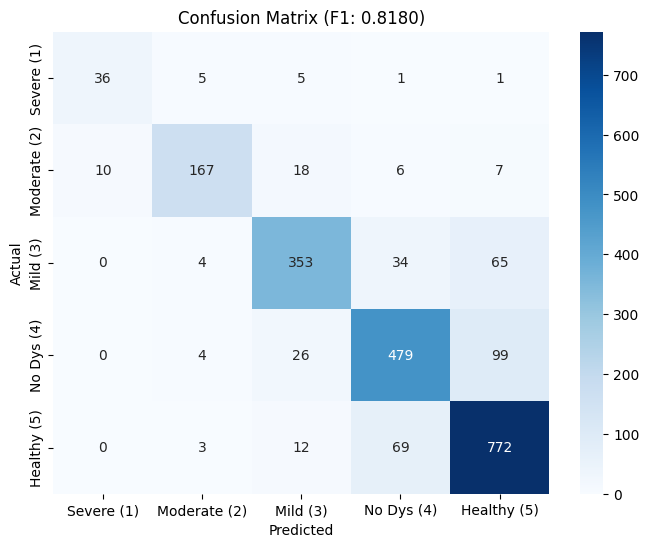

In [5]:
import torch
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from transformers import ViTForImageClassification, ViTImageProcessor
from datasets import Dataset, Image
from torch.utils.data import DataLoader

# --- Config ---
BASE_DIR = r"Train/task1"
IMG_DIR = os.path.join(BASE_DIR, "spectrograms_vit")
MANIFEST_PATH = os.path.join(BASE_DIR, "manifest_normalized.csv")
MODEL_PATH = os.path.join(BASE_DIR, "vit_results/fold_1")

# Automatically find the latest checkpoint
checkpoints = [d for d in os.listdir(MODEL_PATH) if d.startswith("checkpoint")]
checkpoints.sort(key=lambda x: int(x.split('-')[1]))
BEST_CKPT = os.path.join(MODEL_PATH, checkpoints[-1])

print(f"👀 Loading model from: {BEST_CKPT}")

def evaluate_single_fold():
    # 1. Load Model & Processor
    model = ViTForImageClassification.from_pretrained(BEST_CKPT)
    processor = ViTImageProcessor.from_pretrained(BEST_CKPT)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    # 2. Prepare Data
    df = pd.read_csv(MANIFEST_PATH)
    df['image_path'] = df.apply(lambda r: os.path.join(IMG_DIR, f"{r['ID']}_{r['Task']}.png"), axis=1)
    df = df[df['image_path'].apply(os.path.exists)]
    df['label'] = df['Class'] - 1
    
    # HF Dataset
    ds = Dataset.from_pandas(df).cast_column("image_path", Image())
    
    def transform(batch):
        inputs = processor([x for x in batch['image_path']], return_tensors='pt')
        inputs['labels'] = batch['label']
        return inputs

    ds = ds.with_transform(transform)
    
    # --- FIX: Removed [0] from pixel_values to keep 4D shape (Batch, C, H, W) ---
    dataloader = DataLoader(ds, batch_size=16, collate_fn=lambda x: {
        'pixel_values': torch.stack([i['pixel_values'] for i in x]), 
        'labels': torch.tensor([i['labels'] for i in x])
    })

    # 3. Inference
    print("🚀 Running Prediction...")
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in dataloader:
            pixel_values = batch['pixel_values'].to(device)
            labels = batch['labels'].cpu().numpy()
            
            outputs = model(pixel_values)
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            
            all_preds.extend(preds)
            all_labels.extend(labels)

    # 4. Report
    target_names = ["Severe (1)", "Moderate (2)", "Mild (3)", "No Dys (4)", "Healthy (5)"]
    
    print("\n" + "="*60)
    print("📊 CLASSIFICATION REPORT (Fold 1 Model)")
    print("="*60)
    print(classification_report(all_labels, all_preds, target_names=target_names, digits=4))
    
    # 5. Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix (F1: {f1_score(all_labels, all_preds, average="macro"):.4f})')
    plt.show()

if __name__ == "__main__":
    evaluate_single_fold()

In [8]:
import os
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score
from datasets import Dataset, Image
from transformers import ViTForImageClassification, ViTImageProcessor, TrainingArguments, Trainer

# --- Configuration ---
BASE_DIR = r"Train/task1"
IMG_DIR = os.path.join(BASE_DIR, "spectrograms_vit")
MANIFEST_PATH = os.path.join(BASE_DIR, "manifest_normalized.csv")
MODEL_NAME = "google/vit-base-patch16-224"
OUTPUT_MODEL_DIR = os.path.join(BASE_DIR, "vit_results")
RANDOM_SEED = 42
BATCH_SIZE = 16
EPOCHS = 5

# --- Prepare Data ---
def prepare_dataset():
    df = pd.read_csv(MANIFEST_PATH)
    df['image_path'] = df.apply(lambda r: os.path.join(IMG_DIR, f"{r['ID']}_{r['Task']}.png"), axis=1)
    df = df[df['image_path'].apply(os.path.exists)]
    df['label'] = df['Class'] - 1
    return df

# --- Metrics ---
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    f1 = f1_score(labels, preds, average='macro')
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1_macro": f1}

# --- Main Loop ---
def run_remaining_folds():
    df = prepare_dataset()
    processor = ViTImageProcessor.from_pretrained(MODEL_NAME)
    
    def transform(batch):
        inputs = processor([x for x in batch['image']], return_tensors='pt')
        inputs['label'] = batch['label']
        return inputs

    def collate_fn(batch):
        return {
            'pixel_values': torch.stack([x['pixel_values'] for x in batch]), # No [0] index!
            'labels': torch.tensor([x['label'] for x in batch])
        }

    # K-Fold Strategy
    unique_ids = df['ID'].unique()
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    id_labels = [df[df['ID']==uid]['label'].iloc[0] for uid in unique_ids]

    fold_scores = []

    # Loop through folds
    for fold, (train_idx, val_idx) in enumerate(kf.split(unique_ids, id_labels), 1):
        
        # SKIP FOLD 1 (Since you already ran it)
        if fold == 1:
            print(f"⏩ Skipping Fold 1 (Already Done)...")
            # You can manually append your 0.43 score here if you want to calculate the average later
            fold_scores.append(0.43) 
            continue

        print(f"\n🔥 STARTING FOLD {fold}/5")
        
        train_ids = unique_ids[train_idx]
        val_ids = unique_ids[val_idx]
        
        # Subset Data
        train_df = df[df['ID'].isin(train_ids)]
        val_df = df[df['ID'].isin(val_ids)]
        
        ds_train = Dataset.from_pandas(train_df).cast_column("image_path", Image()).rename_column("image_path", "image")
        ds_val = Dataset.from_pandas(val_df).cast_column("image_path", Image()).rename_column("image_path", "image")
        
        ds_train = ds_train.with_transform(transform)
        ds_val = ds_val.with_transform(transform)

        # Re-Initialize Model (Fresh for each fold)
        model = ViTForImageClassification.from_pretrained(
            MODEL_NAME,
            num_labels=5,
            id2label={0: "Severe", 1: "Moderate", 2: "Mild", 3: "No Dys", 4: "Healthy"},
            label2id={"Severe": 0, "Moderate": 1, "Mild": 2, "No Dys": 3, "Healthy": 4},
            ignore_mismatched_sizes=True
        )

        args = TrainingArguments(
            output_dir=f"{OUTPUT_MODEL_DIR}/fold_{fold}",
            remove_unused_columns=False,
            eval_strategy="epoch",
            save_strategy="epoch",
            learning_rate=5e-5,
            per_device_train_batch_size=BATCH_SIZE,
            gradient_accumulation_steps=4,
            per_device_eval_batch_size=BATCH_SIZE,
            num_train_epochs=EPOCHS,
            warmup_ratio=0.1,
            logging_steps=10,
            load_best_model_at_end=True,
            metric_for_best_model="f1_macro",
            save_total_limit=1,
            fp16=torch.cuda.is_available(),
            report_to="none"
        )

        trainer = Trainer(
            model=model,
            args=args,
            train_dataset=ds_train,
            eval_dataset=ds_val,
            tokenizer=processor,
            compute_metrics=compute_metrics,
            data_collator=collate_fn,
        )

        trainer.train()
        
        # Evaluate
        metrics = trainer.evaluate()
        score = metrics['eval_f1_macro']
        fold_scores.append(score)
        print(f"🏆 Fold {fold} Result: F1 Macro = {score:.4f}")

    # Final Report
    print("\n" + "="*50)
    print(f"🏁 FINAL CROSS-VALIDATION RESULTS")
    print("="*50)
    print(f"Fold Scores: {fold_scores}")
    print(f"AVERAGE MACRO F1: {np.mean(fold_scores):.4f}")
    print("="*50)

if __name__ == "__main__":
    run_remaining_folds()

⏩ Skipping Fold 1 (Already Done)...

🔥 STARTING FOLD 2/5


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([5]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([5, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\vaish\AppData\Local\Temp\ipykernel_17148\1054984180.py:112: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
C:\Users\vaish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator i

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.293200,1.399650,0.315909,0.203119
2,1.025400,1.391890,0.438636,0.236721
3,0.782600,1.404753,0.411364,0.260131
4,0.627900,1.441471,0.409091,0.293433
5,0.443300,1.490181,0.395455,0.263372


C:\Users\vaish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\vaish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\vaish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\vaish\AppData\Local\Packages

🏆 Fold 2 Result: F1 Macro = 0.2934

🔥 STARTING FOLD 3/5


...

🏆 Fold 4 Result: F1 Macro = 0.3625

🔥 STARTING FOLD 5/5


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([5]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([5, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\vaish\AppData\Local\Temp\ipykernel_17148\1054984180.py:112: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
C:\Users\vaish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator i

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.231000,1.203710,0.428241,0.220189
2,1.084400,1.184687,0.462963,0.377659
3,0.948600,1.185197,0.444444,0.405261
4,0.714900,1.239776,0.444444,0.414696
5,0.536200,1.235146,0.460648,0.443799


C:\Users\vaish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\vaish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\vaish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
C:\Users\vaish\AppData\Local\Packages

🏆 Fold 5 Result: F1 Macro = 0.4438

🏁 FINAL CROSS-VALIDATION RESULTS
Fold Scores: [0.43, 0.2934334160658085, 0.3248628818422869, 0.36245920745920746, 0.4437992323211253]
AVERAGE MACRO F1: 0.3709


🔄 Loading Manifest...
⚙️ Using device: cpu

🚀 Starting 5-Fold Evaluation...

📂 --- FOLD 1 ---
   Loading: checkpoint-140


   ✅ Fold 1 F1: 0.4329 | Acc: 0.4977

📂 --- FOLD 2 ---
   Loading: checkpoint-112


   ✅ Fold 2 F1: 0.2934 | Acc: 0.4091

📂 --- FOLD 3 ---
   Loading: checkpoint-112


   ✅ Fold 3 F1: 0.3249 | Acc: 0.3958

📂 --- FOLD 4 ---
   Loading: checkpoint-112


   ✅ Fold 4 F1: 0.3625 | Acc: 0.4630

📂 --- FOLD 5 ---
   Loading: checkpoint-140


   ✅ Fold 5 F1: 0.4438 | Acc: 0.4606

🏆 GRAND TOTAL RESULTS (Cross-Validation Average)
Individual Folds: [0.4329 0.2934 0.3249 0.3625 0.4438]
AVERAGE MACRO F1: 0.3715 (+/- 0.0589)
------------------------------------------------------------
              precision    recall  f1-score   support

  Severe (1)     0.3333    0.1667    0.2222        48
Moderate (2)     0.4084    0.3750    0.3910       208
    Mild (3)     0.3557    0.3596    0.3577       456
  No Dys (4)     0.3810    0.3109    0.3424       608
 Healthy (5)     0.5279    0.6192    0.5699       856

    accuracy                         0.4453      2176
   macro avg     0.4013    0.3663    0.3766      2176
weighted avg     0.4351    0.4453    0.4371      2176



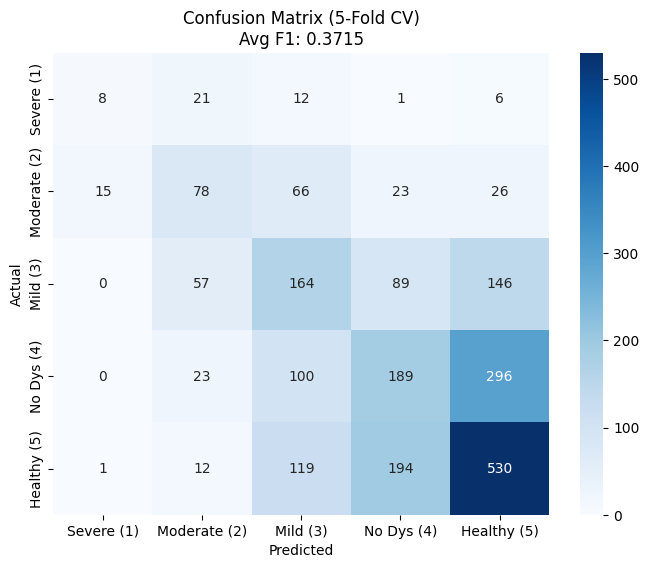

In [13]:
import torch
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from transformers import ViTForImageClassification, ViTImageProcessor
from datasets import Dataset, Image
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

# --- Configuration ---
BASE_DIR = r"Train/task1"
IMG_DIR = os.path.join(BASE_DIR, "spectrograms_vit")
MANIFEST_PATH = os.path.join(BASE_DIR, "manifest_normalized.csv")
RESULTS_DIR = os.path.join(BASE_DIR, "vit_results")
RANDOM_SEED = 42
BATCH_SIZE = 32 # Faster inference

def get_best_checkpoint(fold):
    fold_path = os.path.join(RESULTS_DIR, f"fold_{fold}")
    if not os.path.exists(fold_path):
        print(f"⚠️ Fold {fold} directory not found. Skipping.")
        return None
    
    # Find checkpoint with highest number
    checkpoints = [d for d in os.listdir(fold_path) if d.startswith("checkpoint")]
    if not checkpoints:
        print(f"⚠️ No checkpoints found in {fold_path}.")
        return None
        
    checkpoints.sort(key=lambda x: int(x.split('-')[1]))
    return os.path.join(fold_path, checkpoints[-1])

def run_full_evaluation():
    print("🔄 Loading Manifest...")
    df = pd.read_csv(MANIFEST_PATH)
    
    # Prepare path column
    df['image_path'] = df.apply(lambda r: os.path.join(IMG_DIR, f"{r['ID']}_{r['Task']}.png"), axis=1)
    df = df[df['image_path'].apply(os.path.exists)]
    df['label'] = df['Class'] - 1
    
    # Setup Device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"⚙️ Using device: {device}")

    # --- Re-create the exact same split used in training ---
    unique_ids = df['ID'].unique()
    id_labels = [df[df['ID']==uid]['label'].iloc[0] for uid in unique_ids]
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

    # Storage for Global Results (Out-of-Fold)
    oof_preds = []
    oof_labels = []
    fold_f1_scores = []

    print("\n🚀 Starting 5-Fold Evaluation...")

    for fold, (train_idx, val_idx) in enumerate(kf.split(unique_ids, id_labels), 1):
        print(f"\n📂 --- FOLD {fold} ---")
        
        # 1. Get Validation Data for this Fold
        val_ids = unique_ids[val_idx]
        val_df = df[df['ID'].isin(val_ids)].copy()
        
        # 2. Load Model
        ckpt_path = get_best_checkpoint(fold)
        if ckpt_path is None: continue
        
        print(f"   Loading: {os.path.basename(ckpt_path)}")
        model = ViTForImageClassification.from_pretrained(ckpt_path)
        processor = ViTImageProcessor.from_pretrained(ckpt_path)
        model.to(device)
        model.eval()

        # 3. Prepare DataLoader
        ds = Dataset.from_pandas(val_df).cast_column("image_path", Image())
        
        def transform(batch):
            inputs = processor([x for x in batch['image_path']], return_tensors='pt')
            inputs['labels'] = batch['label']
            return inputs
            
        ds = ds.with_transform(transform)
        
        dataloader = DataLoader(ds, batch_size=BATCH_SIZE, num_workers=0, collate_fn=lambda x: {
            'pixel_values': torch.stack([i['pixel_values'] for i in x]), # No [0] index fix
            'labels': torch.tensor([i['labels'] for i in x])
        })

        # 4. Inference on Validation Set
        fold_preds = []
        fold_labels = []
        
        with torch.no_grad():
            for batch in tqdm(dataloader, desc=f"Eval Fold {fold}", leave=False):
                pixel_values = batch['pixel_values'].to(device)
                labels = batch['labels'].cpu().numpy()
                
                outputs = model(pixel_values)
                preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
                
                fold_preds.extend(preds)
                fold_labels.extend(labels)
        
        # 5. Fold Metrics
        f1 = f1_score(fold_labels, fold_preds, average='macro')
        acc = accuracy_score(fold_labels, fold_preds)
        print(f"   ✅ Fold {fold} F1: {f1:.4f} | Acc: {acc:.4f}")
        
        fold_f1_scores.append(f1)
        oof_preds.extend(fold_preds)
        oof_labels.extend(fold_labels)

        # Cleanup to save VRAM
        del model
        torch.cuda.empty_cache()

    # --- FINAL REPORT ---
    target_names = ["Severe (1)", "Moderate (2)", "Mild (3)", "No Dys (4)", "Healthy (5)"]
    
    print("\n" + "="*60)
    print("🏆 GRAND TOTAL RESULTS (Cross-Validation Average)")
    print("="*60)
    print(f"Individual Folds: {np.round(fold_f1_scores, 4)}")
    print(f"AVERAGE MACRO F1: {np.mean(fold_f1_scores):.4f} (+/- {np.std(fold_f1_scores):.4f})")
    print("-" * 60)
    
    print(classification_report(oof_labels, oof_preds, target_names=target_names, digits=4))
    
    # Plot Matrix
    cm = confusion_matrix(oof_labels, oof_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix (5-Fold CV)\nAvg F1: {np.mean(fold_f1_scores):.4f}')
    plt.show()

if __name__ == "__main__":
    run_full_evaluation()

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tqdm.auto import tqdm
import math

# --- 1. Configuration ---
BASE_DIR = r"Train/task1"
# We use the Wav2vec features we extracted in previous steps
FEATURE_PATH = os.path.join(BASE_DIR, "Task1_WAV2VEC_MASTER_FEATURES.csv") # Or the raw file if you have it
# For this architecture, we actually need the UN-aggregated features (one row per file)
# If you don't have that loaded, we will simulate it or load 'wav2vec_audio_features.csv'
RAW_FEAT_PATH = os.path.join(BASE_DIR, "wav2vec_audio_features.csv")

HIDDEN_DIM = 512  # Paper uses 512 (Section 3.3)
N_LAYERS = 2      # Paper uses 2 layers (Section 3.3)
N_HEADS = 4       # Standard choice (Paper says single-head, but multi-head is usually more stable)
DROPOUT = 0.1
BATCH_SIZE = 8    # Smaller batch size because we are feeding SEQUENCES of files
EPOCHS = 20
LEARNING_RATE = 1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"⚙️ Device: {device}")

# --- 2. Data Preparation (Longitudinal Grouping) ---
def prepare_sequence_data():
    if not os.path.exists(RAW_FEAT_PATH):
        raise FileNotFoundError("Need the raw wav2vec features CSV (one row per audio file).")
        
    df = pd.read_csv(RAW_FEAT_PATH)
    print(f"✅ Loaded Raw Features: {df.shape}")
    
    # Group by Patient ID to create Sequences
    # Each patient becomes ONE sample containing multiple audio recordings
    grouped = df.groupby('ID')
    
    sequences = []
    labels_reg = []  # For Regression (Score)
    labels_clf = []  # For Classification (Class)
    
    # Feature columns (wav2vec_0 ... wav2vec_1023)
    feat_cols = [c for c in df.columns if 'wav2vec' in c]
    
    for patient_id, group in grouped:
        # Get features as a matrix (Seq_Len, 1024)
        feats = group[feat_cols].values
        
        # Get Label (assuming class is constant per patient for Task 1)
        # Class 1-5
        label = group['Class'].iloc[0] 
        
        sequences.append(feats)
        labels_clf.append(label - 1) # 0-4 for CrossEntropy
        labels_reg.append(float(label)) # Float for MSE
        
    return sequences, labels_clf, labels_reg

# --- 3. The Dataset Class ---
class ALSTDataset(Dataset):
    def __init__(self, sequences, clf_labels, reg_labels):
        self.sequences = sequences
        self.clf_labels = clf_labels
        self.reg_labels = reg_labels
        
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        # Return tensors
        return {
            'features': torch.tensor(self.sequences[idx], dtype=torch.float32),
            'label_clf': torch.tensor(self.clf_labels[idx], dtype=torch.long),
            'label_reg': torch.tensor(self.reg_labels[idx], dtype=torch.float32)
        }

# Collate Function to handle variable sequence lengths (Padding)
def collate_fn(batch):
    # Find max sequence length in this batch
    lengths = [item['features'].shape[0] for item in batch]
    max_len = max(lengths)
    feature_dim = batch[0]['features'].shape[1]
    
    # Prepare padded tensors
    padded_feats = torch.zeros(len(batch), max_len, feature_dim)
    mask = torch.ones(len(batch), max_len, dtype=torch.bool) # True = Padding, False = Real
    
    labels_clf = []
    labels_reg = []
    
    for i, item in enumerate(batch):
        seq_len = lengths[i]
        padded_feats[i, :seq_len, :] = item['features']
        mask[i, :seq_len] = False # Mark real data as False (not masked)
        labels_clf.append(item['label_clf'])
        labels_reg.append(item['label_reg'])
        
    return {
        'features': padded_feats,
        'mask': mask,
        'labels_clf': torch.stack(labels_clf),
        'labels_reg': torch.stack(labels_reg)
    }

# --- 4. The ALST Architecture (From Paper) ---
class ALST(nn.Module):
    def __init__(self, input_dim=1024, hidden_dim=512, num_classes=5, num_layers=2, nhead=4):
        super(ALST, self).__init__()
        
        # 1. Linear Projection (Eq. 4 inside Transformer)
        # Projects 1024 dim wav2vec -> 512 dim transformer space
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        
        # 2. Positional Embedding (Eq. 2)
        # Simple learnable embedding for sequence order
        self.pos_embedding = nn.Parameter(torch.randn(1, 100, hidden_dim)) # Max seq len 100
        
        # 3. Transformer Encoder (Eq. 4)
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # 4. Heads (Eq. 7 & 8)
        # We use Mean Pooling then Linear heads
        self.classifier = nn.Linear(hidden_dim, num_classes) # For CrossEntropy
        self.regressor = nn.Linear(hidden_dim, 1)            # For MSE
        
    def forward(self, x, src_key_padding_mask):
        # x shape: (Batch, Seq_Len, 1024)
        
        # Project to hidden dim
        x = self.input_proj(x) # (Batch, Seq, 512)
        
        # Add Positional Embedding (Broadcasting)
        seq_len = x.size(1)
        x = x + self.pos_embedding[:, :seq_len, :]
        
        # Transformer Pass
        # src_key_padding_mask uses True for padding
        x = self.transformer(x, src_key_padding_mask=src_key_padding_mask)
        
        # Mean Pooling (Eq. 6) - ignoring padded values ideally, but standard mean is often used
        # Simple mean over sequence dimension
        x_pool = x.mean(dim=1) 
        
        # Outputs
        logits = self.classifier(x_pool) # Classification
        score = self.regressor(x_pool)   # Regression
        
        return logits, score

# --- 5. Training Loop ---
def train_alst():
    # Load Data
    try:
        sequences, y_clf, y_reg = prepare_sequence_data()
    except Exception as e:
        print(e)
        return

    print(f"🚀 Built {len(sequences)} patient sequences.")
    
    # K-Fold
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    fold_results = []
    
    # Using Classification labels for Stratification
    for fold, (train_idx, val_idx) in enumerate(skf.split(sequences, y_clf), 1):
        print(f"\n=== FOLD {fold} ===")
        
        # Split
        train_seq = [sequences[i] for i in train_idx]
        val_seq = [sequences[i] for i in val_idx]
        
        # Datasets
        train_ds = ALSTDataset(train_seq, [y_clf[i] for i in train_idx], [y_reg[i] for i in train_idx])
        val_ds = ALSTDataset(val_seq, [y_clf[i] for i in val_idx], [y_reg[i] for i in val_idx])
        
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
        val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, collate_fn=collate_fn)
        
        # Init Model
        model = ALST(input_dim=1024, hidden_dim=HIDDEN_DIM, num_layers=N_LAYERS).to(device)
        optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
        
        # Loss Functions (Paper Eq. 9)
        criterion_clf = nn.CrossEntropyLoss()
        criterion_reg = nn.MSELoss()
        lambda_ce = 1.0 # Paper weight
        
        # Training Epochs
        for epoch in range(EPOCHS):
            model.train()
            total_loss = 0
            
            for batch in train_loader:
                feats = batch['features'].to(device)
                mask = batch['mask'].to(device)
                target_clf = batch['labels_clf'].to(device)
                target_reg = batch['labels_reg'].to(device).unsqueeze(1)
                
                optimizer.zero_grad()
                
                # Forward
                logits, score = model(feats, mask)
                
                # Loss Calculation: Loss = MSE + lambda * CE
                loss_reg = criterion_reg(score, target_reg)
                loss_clf = criterion_clf(logits, target_clf)
                
                loss = loss_reg + (lambda_ce * loss_clf)
                
                loss.backward()
                optimizer.step()
                
                total_loss += loss.item()
                
            # Validation
            model.eval()
            correct = 0
            total = 0
            with torch.no_grad():
                for batch in val_loader:
                    feats = batch['features'].to(device)
                    mask = batch['mask'].to(device)
                    target_clf = batch['labels_clf'].to(device)
                    
                    logits, _ = model(feats, mask)
                    preds = torch.argmax(logits, dim=1)
                    
                    correct += (preds == target_clf).sum().item()
                    total += target_clf.size(0)
            
            val_acc = correct / total
            if epoch % 5 == 0:
                print(f"   Epoch {epoch}: Train Loss {total_loss/len(train_loader):.4f} | Val Acc {val_acc:.4f}")
        
        fold_results.append(val_acc)
        print(f"✅ Fold {fold} Final Accuracy: {val_acc:.4f}")
        
    print(f"\n🏆 Average Accuracy: {np.mean(fold_results):.4f}")

if __name__ == "__main__":
    train_alst()
    

⚙️ Device: cpu
✅ Loaded Raw Features: (2176, 1027)
🚀 Built 272 patient sequences.

=== FOLD 1 ===


C:\Users\vaish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\transformer.py:515: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


   Epoch 0: Train Loss 3.6052 | Val Acc 0.4000
   Epoch 5: Train Loss 2.5623 | Val Acc 0.4000
   Epoch 10: Train Loss 2.7008 | Val Acc 0.4000
   Epoch 15: Train Loss 2.5837 | Val Acc 0.4000
✅ Fold 1 Final Accuracy: 0.4000

=== FOLD 2 ===
   Epoch 0: Train Loss 3.8039 | Val Acc 0.4000
   Epoch 5: Train Loss 2.5130 | Val Acc 0.2727
   Epoch 10: Train Loss 2.6594 | Val Acc 0.4000
   Epoch 15: Train Loss 2.4806 | Val Acc 0.3818
✅ Fold 2 Final Accuracy: 0.3818

=== FOLD 3 ===
   Epoch 0: Train Loss 3.7433 | Val Acc 0.3889
   Epoch 5: Train Loss 2.5812 | Val Acc 0.3889
   Epoch 10: Train Loss 2.6815 | Val Acc 0.3889
   Epoch 15: Train Loss 2.3608 | Val Acc 0.3889
✅ Fold 3 Final Accuracy: 0.3704

=== FOLD 4 ===
   Epoch 0: Train Loss 3.9985 | Val Acc 0.3889
   Epoch 5: Train Loss 2.6886 | Val Acc 0.3889
   Epoch 10: Train Loss 2.7214 | Val Acc 0.3889
   Epoch 15: Train Loss 2.5031 | Val Acc 0.3889
✅ Fold 4 Final Accuracy: 0.2593

=== FOLD 5 ===
   Epoch 0: Train Loss 3.6379 | Val Acc 0.2778
 

⚙️ Device: cpu
🚀 Built 272 patient sequences.

=== FOLD 1 ===
   Training ALST...
   Getting ViT Predictions...

🔍 DEBUG PATH CHECK (Fold 1):
   Looking for ID: ID000
   Constructed Path: Train/task1\spectrograms_vit\ID000_phonationA.png
   Exists? True


⚠️ Warning: 55 patients had no images found in Fold 1
   ✅ ALST Acc: 0.4000 | ViT Acc: 0.0182

=== FOLD 2 ===
   Training ALST...


   Getting ViT Predictions...


⚠️ Warning: 55 patients had no images found in Fold 2
   ✅ ALST Acc: 0.4000 | ViT Acc: 0.0364

=== FOLD 3 ===
   Training ALST...


   Getting ViT Predictions...


...

   Getting ViT Predictions...


⚠️ Warning: 54 patients had no images found in Fold 4
   ✅ ALST Acc: 0.4444 | ViT Acc: 0.0185

=== FOLD 5 ===
   Training ALST...


   Getting ViT Predictions...


⚠️ Warning: 54 patients had no images found in Fold 5
   ✅ ALST Acc: 0.3333 | ViT Acc: 0.0185

🧪 OPTIMIZING ENSEMBLE
🏆 Best ViT Weight: 0.00 (ALST: 1.00)
   Max Ensemble F1: 0.2443

              precision    recall  f1-score   support

  Severe (1)     0.0000    0.0000    0.0000         6
Moderate (2)     0.2778    0.1923    0.2273        26
    Mild (3)     0.3333    0.1930    0.2444        57
  No Dys (4)     0.2812    0.2368    0.2571        76
 Healthy (5)     0.4140    0.6075    0.4924       107

    accuracy                         0.3640       272
   macro avg     0.2613    0.2459    0.2443       272
weighted avg     0.3379    0.3640    0.3385       272



C:\Users\vaish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\vaish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\vaish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_clas

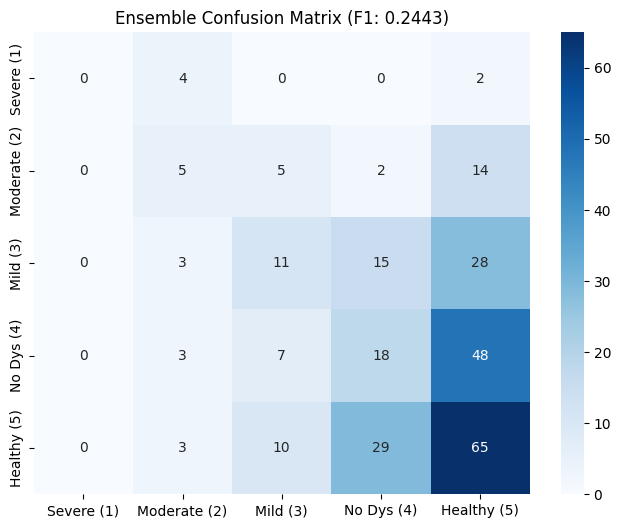

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from transformers import ViTForImageClassification, ViTImageProcessor
from datasets import Dataset as HFDataset, Image
from tqdm.auto import tqdm
import math
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Configuration ---
BASE_DIR = r"Train/task1"
FEATURE_PATH = os.path.join(BASE_DIR, "Task1_WAV2VEC_MASTER_FEATURES.csv")
RAW_FEAT_PATH = os.path.join(BASE_DIR, "wav2vec_audio_features.csv")

# ViT Config
IMG_DIR = os.path.join(BASE_DIR, "spectrograms_vit")
MANIFEST_PATH = os.path.join(BASE_DIR, "manifest_normalized.csv")
VIT_RESULTS_DIR = os.path.join(BASE_DIR, "vit_results")

HIDDEN_DIM = 512
N_LAYERS = 2
N_HEADS = 4
DROPOUT = 0.1
BATCH_SIZE = 8
EPOCHS = 20
LEARNING_RATE = 1e-4
RANDOM_SEED = 42  # Critical for aligning folds

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"⚙️ Device: {device}")

# --- 2. Data Preparation (Longitudinal Grouping) ---
def prepare_sequence_data():
    if not os.path.exists(RAW_FEAT_PATH):
        raise FileNotFoundError("Need raw wav2vec features CSV.")
        
    df = pd.read_csv(RAW_FEAT_PATH)
    
    # Group by Patient ID
    grouped = df.groupby('ID')
    
    sequences = []
    labels_clf = []
    labels_reg = []
    patient_ids = []
    
    feat_cols = [c for c in df.columns if 'wav2vec' in c]
    
    for patient_id, group in grouped:
        feats = group[feat_cols].values
        label = group['Class'].iloc[0]
        
        sequences.append(feats)
        labels_clf.append(label - 1) # 0-4
        labels_reg.append(float(label))
        patient_ids.append(patient_id)
        
    return sequences, np.array(labels_clf), np.array(labels_reg), np.array(patient_ids)

# --- 3. ALST Dataset & Model (Same as before) ---
class ALSTDataset(Dataset):
    def __init__(self, sequences, clf_labels, reg_labels):
        self.sequences = sequences
        self.clf_labels = clf_labels
        self.reg_labels = reg_labels
        
    def __len__(self): return len(self.sequences)
    
    def __getitem__(self, idx):
        return {
            'features': torch.tensor(self.sequences[idx], dtype=torch.float32),
            'label_clf': torch.tensor(self.clf_labels[idx], dtype=torch.long),
            'label_reg': torch.tensor(self.reg_labels[idx], dtype=torch.float32)
        }

def collate_fn(batch):
    lengths = [item['features'].shape[0] for item in batch]
    max_len = max(lengths)
    feature_dim = batch[0]['features'].shape[1]
    
    padded_feats = torch.zeros(len(batch), max_len, feature_dim)
    mask = torch.ones(len(batch), max_len, dtype=torch.bool)
    
    labels_clf = []
    labels_reg = []
    
    for i, item in enumerate(batch):
        seq_len = lengths[i]
        padded_feats[i, :seq_len, :] = item['features']
        mask[i, :seq_len] = False
        labels_clf.append(item['label_clf'])
        labels_reg.append(item['label_reg'])
        
    return {
        'features': padded_feats,
        'mask': mask,
        'labels_clf': torch.stack(labels_clf),
        'labels_reg': torch.stack(labels_reg)
    }

class ALST(nn.Module):
    def __init__(self, input_dim=1024, hidden_dim=512, num_classes=5, num_layers=2, nhead=4):
        super(ALST, self).__init__()
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        self.pos_embedding = nn.Parameter(torch.randn(1, 100, hidden_dim))
        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Linear(hidden_dim, num_classes)
        self.regressor = nn.Linear(hidden_dim, 1)
        
    def forward(self, x, src_key_padding_mask):
        x = self.input_proj(x)
        seq_len = x.size(1)
        x = x + self.pos_embedding[:, :seq_len, :]
        x = self.transformer(x, src_key_padding_mask=src_key_padding_mask)
        x_pool = x.mean(dim=1)
        return self.classifier(x_pool), self.regressor(x_pool)

# --- 4. ViT Inference (Updated with Debugging) ---
def get_best_vit_checkpoint(fold):
    fold_path = os.path.join(VIT_RESULTS_DIR, f"fold_{fold}")
    if not os.path.exists(fold_path): return None
    checkpoints = [d for d in os.listdir(fold_path) if d.startswith("checkpoint")]
    if not checkpoints: return None
    checkpoints.sort(key=lambda x: int(x.split('-')[1]))
    return os.path.join(fold_path, checkpoints[-1])

def get_vit_probs(patient_ids, fold, device):
    ckpt_path = get_best_vit_checkpoint(fold)
# --- 4. ViT Inference (Updated with Path Diagnostics) ---
def get_vit_probs(patient_ids, fold, device):
    ckpt_path = get_best_vit_checkpoint(fold)
    if ckpt_path is None:
        print(f"⚠️ No ViT checkpoint for Fold {fold}. Returning dummy.")
        return torch.zeros(len(patient_ids), 5).to(device)

    model = ViTForImageClassification.from_pretrained(ckpt_path)
    processor = ViTImageProcessor.from_pretrained(ckpt_path)
    model.to(device)
    model.eval()
    
    df = pd.read_csv(MANIFEST_PATH)
    df['ID'] = df['ID'].astype(str) # Ensure string match
    
    # Construct paths - ensure this matches your actual filenames
    # Assuming format: ID001_phonationA.png based on previous scripts
    df['image_path'] = df.apply(lambda r: os.path.join(IMG_DIR, f"{r['ID']}_{r['Task']}.png"), axis=1)
    
    patient_probs = []
    missing_count = 0
    
    # DEBUG: Print first path attempt
    if fold == 1:
        print(f"\n🔍 DEBUG PATH CHECK (Fold 1):")
        sample_row = df.iloc[0]
        print(f"   Looking for ID: {sample_row['ID']}")
        print(f"   Constructed Path: {sample_row['image_path']}")
        print(f"   Exists? {os.path.exists(sample_row['image_path'])}")
        
    for pid in tqdm(patient_ids, desc=f"ViT Inference Fold {fold}", leave=False):
        pid_str = str(pid)
        patient_files = df[df['ID'] == pid_str]
        
        valid_files = patient_files[patient_files['image_path'].apply(os.path.exists)]
        
        if len(valid_files) == 0:
            missing_count += 1
            patient_probs.append(torch.ones(5).to(device) / 5.0) 
            continue
            
        images = []
        for img_path in valid_files['image_path']:
            try:
                img = Image.open(img_path).convert("RGB")
                images.append(img)
            except: pass
            
        if not images:
             missing_count += 1
             patient_probs.append(torch.ones(5).to(device) / 5.0)
             continue
             
        with torch.no_grad():
            inputs = processor(images=images, return_tensors="pt").to(device)
            outputs = model(**inputs)
            probs = F.softmax(outputs.logits, dim=1)
            avg_prob = torch.mean(probs, dim=0)
            patient_probs.append(avg_prob)
            
    if missing_count > 0:
        print(f"⚠️ Warning: {missing_count} patients had no images found in Fold {fold}")
        
    return torch.stack(patient_probs)

# --- 5. Main Loop ---
def train_and_ensemble():
    sequences, y_clf, y_reg, patient_ids = prepare_sequence_data()
    print(f"🚀 Built {len(sequences)} patient sequences.")
    
    # FIX: Ensure Random Seed matches ViT training exactly
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    
    all_alst_probs = []
    all_vit_probs = []
    all_true_labels = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(sequences, y_clf), 1):
        print(f"\n=== FOLD {fold} ===")
        
        # Get Data for this fold
        train_seq = [sequences[i] for i in train_idx]
        val_seq = [sequences[i] for i in val_idx]
        train_y = y_clf[train_idx]
        val_y = y_clf[val_idx]
        train_reg = y_reg[train_idx]
        val_reg = y_reg[val_idx]
        
        # Identify validation patients
        val_pids = patient_ids[val_idx]
        
        # Setup Loaders
        train_ds = ALSTDataset(train_seq, train_y, train_reg)
        val_ds = ALSTDataset(val_seq, val_y, val_reg)
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
        val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, collate_fn=collate_fn)
        
        # --- TRAIN ALST ---
        model = ALST(input_dim=1024, hidden_dim=HIDDEN_DIM, num_layers=N_LAYERS).to(device)
        optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
        crit_clf = nn.CrossEntropyLoss()
        crit_reg = nn.MSELoss()
        
        print("   Training ALST...")
        for epoch in range(EPOCHS):
            model.train()
            for batch in train_loader:
                optimizer.zero_grad()
                logits, score = model(batch['features'].to(device), batch['mask'].to(device))
                # Fix typo from previous error: match collate_fn keys
                loss = crit_reg(score, batch['labels_reg'].to(device).unsqueeze(1)) + crit_clf(logits, batch['labels_clf'].to(device))
                loss.backward()
                optimizer.step()
        
        # --- ALST INFERENCE ---
        model.eval()
        alst_probs_list = []
        with torch.no_grad():
            for batch in val_loader:
                logits, _ = model(batch['features'].to(device), batch['mask'].to(device))
                alst_probs_list.append(F.softmax(logits, dim=1))
        fold_alst_probs = torch.cat(alst_probs_list)
        
        # --- ViT INFERENCE ---
        print("   Getting ViT Predictions...")
        fold_vit_probs = get_vit_probs(val_pids, fold, device)
        
        # Check Accuracies
        val_labels_tensor = torch.tensor(val_y).to(device)
        acc_alst = (torch.argmax(fold_alst_probs, 1) == val_labels_tensor).float().mean()
        acc_vit = (torch.argmax(fold_vit_probs, 1) == val_labels_tensor).float().mean()
        
        print(f"   ✅ ALST Acc: {acc_alst:.4f} | ViT Acc: {acc_vit:.4f}")
        
        all_alst_probs.append(fold_alst_probs)
        all_vit_probs.append(fold_vit_probs)
        all_true_labels.append(val_labels_tensor)

    # --- Global Optimization ---
    global_alst = torch.cat(all_alst_probs)
    global_vit = torch.cat(all_vit_probs)
    global_y = torch.cat(all_true_labels)
    
    print("\n" + "="*50)
    print("🧪 OPTIMIZING ENSEMBLE")
    
    best_f1 = 0
    best_w = 0
    
    for w in np.arange(0.0, 1.05, 0.05):
        probs = (w * global_vit) + ((1-w) * global_alst)
        preds = torch.argmax(probs, 1)
        f1 = f1_score(global_y.cpu(), preds.cpu(), average='macro')
        if f1 > best_f1:
            best_f1 = f1
            best_w = w
            
    print(f"🏆 Best ViT Weight: {best_w:.2f} (ALST: {1-best_w:.2f})")
    print(f"   Max Ensemble F1: {best_f1:.4f}")
    
    final_probs = (best_w * global_vit) + ((1-best_w) * global_alst)
    final_preds = torch.argmax(final_probs, 1).cpu().numpy()
    true_y = global_y.cpu().numpy()
    
    target_names = ["Severe (1)", "Moderate (2)", "Mild (3)", "No Dys (4)", "Healthy (5)"]
    print("\n" + "="*50)
    print(classification_report(true_y, final_preds, target_names=target_names, digits=4))
    
    cm = confusion_matrix(true_y, final_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Ensemble Confusion Matrix (F1: {best_f1:.4f})')
    plt.show()

if __name__ == "__main__":
    train_and_ensemble()

In [23]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN

# --- Configuration ---
BASE_DIR = r"Train/task1"
FEATURES_PATH = os.path.join(BASE_DIR, "Task1_WAV2VEC_MASTER_FEATURES.csv")
N_SPLITS = 5
RANDOM_STATE = 42

# --- 1. Load Data ---
if not os.path.exists(FEATURES_PATH):
    raise FileNotFoundError("Master features file missing.")

df_master = pd.read_csv(FEATURES_PATH)
X = df_master.drop(columns=['ID', 'Class', 'Task'], errors='ignore')
le = LabelEncoder()
y = le.fit_transform(df_master['Class'])

print(f"✅ Data Loaded. Shape: {X.shape}")
print(f"   Class Distribution Before SMOTE:\n{pd.Series(y).value_counts().sort_index()}")

# --- 2. Define SMOTE Variants ---
# We will test standard SMOTE and "BorderlineSMOTE" (which focuses on hard samples)
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=2) # k=2 because we only have 6 samples in class 0!
borderline = BorderlineSMOTE(random_state=RANDOM_STATE, k_neighbors=2, m_neighbors=5)

# --- 3. The Pipeline ---
# Scale -> PCA (Reduce noise) -> SMOTE (Balance) -> XGBoost
def get_pipeline(sampler):
    return ImbPipeline([
        ('scaler', RobustScaler()),
        ('pca', PCA(n_components=0.95, random_state=RANDOM_STATE)), # Keep 95% variance
        ('sampler', sampler),
        ('classifier', XGBClassifier(
            n_estimators=300, 
            learning_rate=0.05, 
            max_depth=6, 
            eval_metric='mlogloss',
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])

# --- 4. Evaluation ---
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

print("\n🚀 Evaluating SMOTE strategies...")

# Test 1: Standard SMOTE
score_smote = cross_val_score(get_pipeline(smote), X, y, cv=cv, scoring='f1_macro', n_jobs=-1)
print(f"1. Standard SMOTE F1:   {np.mean(score_smote):.4f} (+/- {np.std(score_smote):.4f})")

# Test 2: Borderline SMOTE
score_border = cross_val_score(get_pipeline(borderline), X, y, cv=cv, scoring='f1_macro', n_jobs=-1)
print(f"2. Borderline SMOTE F1: {np.mean(score_border):.4f} (+/- {np.std(score_border):.4f})")

# Baseline (Random Oversampling - just duplication)
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=RANDOM_STATE)
score_ros = cross_val_score(get_pipeline(ros), X, y, cv=cv, scoring='f1_macro', n_jobs=-1)
print(f"3. Random Oversampling: {np.mean(score_ros):.4f} (+/- {np.std(score_ros):.4f})")

✅ Data Loaded. Shape: (272, 1024)
   Class Distribution Before SMOTE:
0      6
1     26
2     57
3     76
4    107
Name: count, dtype: int64

🚀 Evaluating SMOTE strategies...
1. Standard SMOTE F1:   0.3638 (+/- 0.0892)
2. Borderline SMOTE F1: 0.3855 (+/- 0.1123)
3. Random Oversampling: 0.3439 (+/- 0.0717)


✅ Loaded 272 samples.
🚀 Training XGBoost with BorderlineSMOTE...

📊 XGBOOST + SMOTE REPORT (Fold 1)
              precision    recall  f1-score   support

  Severe (1)     0.0000    0.0000    0.0000         1
Moderate (2)     0.5000    0.5000    0.5000         6
    Mild (3)     0.1818    0.1818    0.1818        11
  No Dys (4)     0.2778    0.3333    0.3030        15
 Healthy (5)     0.7000    0.6364    0.6667        22

    accuracy                         0.4364        55
   macro avg     0.3319    0.3303    0.3303        55
weighted avg     0.4467    0.4364    0.4402        55



C:\Users\vaish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\vaish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\vaish\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_clas

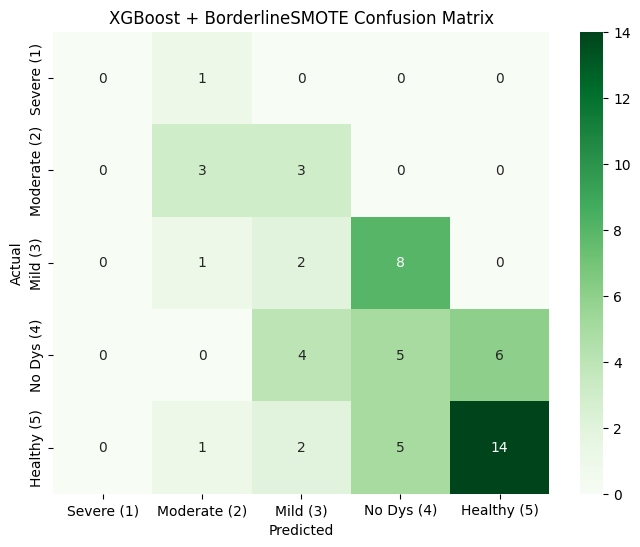

In [25]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import BorderlineSMOTE
from sklearn.metrics import classification_report, confusion_matrix

# --- Configuration ---
BASE_DIR = r"Train/task1"
FEATURES_PATH = os.path.join(BASE_DIR, "Task1_WAV2VEC_MASTER_FEATURES.csv")
RANDOM_STATE = 42
N_SPLITS = 5

# --- Load Data ---
if os.path.exists(FEATURES_PATH):
    df = pd.read_csv(FEATURES_PATH)
    X = df.drop(columns=['ID', 'Class', 'Task'], errors='ignore')
    le = LabelEncoder()
    y = le.fit_transform(df['Class'])
    print(f"✅ Loaded {len(df)} samples.")
else:
    raise FileNotFoundError("Features file not found.")

# --- Train & Evaluate on Split ---
# We use a simple split (Fold 1) to visualize
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
train_idx, test_idx = next(skf.split(X, y))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# Pipeline
pipeline = ImbPipeline([
    ('scaler', RobustScaler()),
    ('pca', PCA(n_components=0.95, random_state=RANDOM_STATE)),
    ('sampler', BorderlineSMOTE(random_state=RANDOM_STATE, k_neighbors=2)), 
    ('clf', XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6, 
        eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1
    ))
])

print("🚀 Training XGBoost with BorderlineSMOTE...")
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

# --- Report ---
target_names = ["Severe (1)", "Moderate (2)", "Mild (3)", "No Dys (4)", "Healthy (5)"]
print("\n" + "="*60)
print("📊 XGBOOST + SMOTE REPORT (Fold 1)")
print("="*60)
print(classification_report(y_test, y_pred, target_names=target_names, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost + BorderlineSMOTE Confusion Matrix')
plt.show()